# Training Projection Accuracy

In [107]:
#!/usr/bin/env python3
"""
Quick comparison of prototype texts between nearest neighbor and optimized models
"""

import torch
import torch.nn.functional as F
import pickle
import pandas as pd


def truncate_to_words(text: str, max_words: int = 190) -> str:
    """Truncate text to first N words."""
    words = text.split()
    if len(words) <= max_words:
        return text
    return ' '.join(words[:max_words]) + '...'


def compare_prototypes(dataset='20newsgroups', model='bert', seed=0, num_protos=3):
    """Compare nearest neighbor vs optimized prototype texts."""
    
    print(f"\nComparing prototypes for {dataset}/{model}/seed{seed}")
    print("="*80)
    
    # Load training texts
    train_df = pd.read_csv(f'datasets/preprocess/{dataset}/train.csv')
    train_texts = train_df['text'].values.tolist()
    
    # Load train encodings
    enc_path = f'datasets/preprocess/{dataset}/train_encodings_toy_{model}_{seed}_False_True.pt'
    train_encodings = torch.load(enc_path, map_location="cpu")
    
    # Load learned prototypes from the saved weights
    weight_path = f'weights/pre_projection_{model}_{dataset}_protos{num_protos}_baselineTrue_seed{seed}_no_llm_headFalse.pt'
    state_dict = torch.load(weight_path, map_location=torch.device('cpu'), weights_only=False)
    learned_prototypes = state_dict['prototypes']
    
    # Find nearest neighbors for each prototype
    train_enc_norm = F.normalize(train_encodings, p=2, dim=1)
    proto_norm = F.normalize(learned_prototypes, p=2, dim=1)
    sims = torch.matmul(proto_norm, train_enc_norm.T)
    nn_indices = torch.argmax(sims, dim=1)
    
    print(f"Found {len(nn_indices)} prototypes\n")
    
    # Load optimized texts from pickle
    pickle_path = f'data/len_run/optimization_exp_all_data_seed{seed}.pickle'
    with open(pickle_path, 'rb') as f:
        data = pickle.load(f)
    
    summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
    opt_texts = data[summary_key].get("optimized_prototype_texts", [])
    
    # Compare first few prototypes
    num_to_show = min(6, len(nn_indices))  # Show first 3 prototypes
    
    for i in range(num_to_show):
        print(f"\nPROTOTYPE {i+1}:")
        print("-"*40)
        
        # Get similarity score for nearest neighbor
        nn_sim = sims[i, nn_indices[i]].item()
        
        # Nearest neighbor text (truncated to 190 words)
        nn_text = train_texts[nn_indices[i]]
        nn_truncated = truncate_to_words(nn_text, 190)
        
        print(f"NEAREST NEIGHBOR (Projected) - Similarity: {nn_sim:.4f}")
        print(nn_truncated)
        
        print("\n" + "-"*20)
        
        # Optimized text (truncated to 190 words)
        if i < len(opt_texts):
            opt_truncated = truncate_to_words(opt_texts[i], 190)
            print("OPTIMIZED (LLM-generated):")
            print(opt_truncated)
        else:
            print("OPTIMIZED: [Not available]")
        
        print("\n" + "="*80)


if __name__ == "__main__":
    # Examples - change these to view different combinations
    compare_prototypes(dataset='imdb', model='roberta', seed=0, num_protos=3)


Comparing prototypes for imdb/roberta/seed0
Found 6 prototypes


PROTOTYPE 1:
----------------------------------------
NEAREST NEIGHBOR (Projected) - Similarity: 0.9995
Sloppily directed, witless comedy that supposedly spoofs the "classic" 50s "alien invasion" films, but really is no better than them, except of course in the purely technical department (good makeup effects). And any spoof that is worse than its target is doomed to fail ("Casino Royale", "Our Man Flint" are worse than almost any James Bond movie). After two hours of hearing the screeching voices of the aliens, you'll be begging for some peace and quiet. (*1/2)

--------------------
OPTIMIZED (LLM-generated):
Spoof movie with subpar technical quality, failing to deliver laughs.


PROTOTYPE 2:
----------------------------------------
NEAREST NEIGHBOR (Projected) - Similarity: 0.9996
The screenplay is the worst part of this film, as it lurches from one premise to the next, missing all the important bits that would have ma

In [90]:
import os, re, glob
import numpy as np
import pandas as pd

# -------------------
# Config
# -------------------
SEARCH_DIRS = ["./data/len_run"]#, "/mnt/data"]
DATASETS    = ['imdb', 'amazon_reviews', 'agnews']
MODELS      = ['bert', 'electra', 'roberta']
SEEDS       = [0,1,2]

# NUM_PROTOS removed - now dynamically loads all available prototype numbers
NO_LLM_HEAD = False

# -------------------
# File pattern
# -------------------
fname_re = re.compile(
    r"^(?P<model>.+?)_(?P<dataset>.+?)_protos(?P<num_protos>\d+)_"
    r"baseline(?P<baseline>True|False)_seed(?P<seed>\d+)_"
    r"no_llm_head(?P<no_llm_head>True|False)\.csv$"
)

# -------------------
# Load CSVs (new schema)
# -------------------
rows = []
for base in SEARCH_DIRS:
    for path in glob.glob(os.path.join(base, "*.csv")):
        fname = os.path.basename(path)
        m = fname_re.match(fname)
        if not m:
            continue
        meta = m.groupdict()
        df = pd.read_csv(path)


        # In the main loading loop, replace the metric extraction with:
        for _, r in df.iterrows():
            rows.append({
                "model": meta["model"],
                "dataset": meta["dataset"],
                "num_protos": int(meta["num_protos"]),
                "baseline": meta["baseline"] == "True",
                "seed": int(meta["seed"]),
                "no_llm_head": meta["no_llm_head"] == "True",
        
                # Handle both val and test column naming
                "orig_val_acc": r.get("orig_val_acc", r.get("orig_test_acc", np.nan)),
                "orig_val_f1_macro": r.get("orig_val_f1_macro", r.get("orig_test_f1_macro", np.nan)),
                "proj_full_val_acc": r.get("proj_full_val_acc", r.get("proj_full_test_acc", np.nan)),
                "proj_full_val_f1_macro": r.get("proj_full_val_f1_macro", r.get("proj_full_test_f1_macro", np.nan)),
            })

combined = pd.DataFrame(rows)

# Filter to what you care about (removed num_protos filter)
combined = combined[
    (combined["no_llm_head"] == NO_LLM_HEAD) &
    (combined["dataset"].isin(DATASETS)) &
    (combined["model"].isin(MODELS)) &
    (combined["seed"].isin(SEEDS)) &
    (combined["baseline"] == True)
].copy()

# Print available prototype numbers
available_protos = sorted(combined["num_protos"].unique())
print(f"Available prototype numbers: {available_protos}")
print(f"Total combinations loaded: {len(combined)}")

# -------------------
# Long-form conversion (2 conditions)
# -------------------
COND_LABELS = [
    "Original",
    "Projected (full)",
]

def make_long2(df, orig_col, full_col, label):
    parts = []
    c_orig = df[["dataset","model","seed","num_protos",orig_col]].rename(columns={orig_col:"metric"})
    c_orig["condition"] = COND_LABELS[0]; parts.append(c_orig)

    c_full = df[["dataset","model","seed","num_protos",full_col]].rename(columns={full_col:"metric"})
    c_full["condition"] = COND_LABELS[1]; parts.append(c_full)

    out = pd.concat(parts, ignore_index=True)
    out["metric_name"] = label
    return out

long_acc = make_long2(
    combined,
    "orig_val_acc",
    "proj_full_val_acc",
    "Accuracy"
)
long_f1 = make_long2(
    combined,
    "orig_val_f1_macro",
    "proj_full_val_f1_macro",
    "F1 macro"
)

# -------------------
# Summaries: mean & standard error
# -------------------
def summarize(long_df, group_cols):
    """
    Returns a DataFrame with mean, std, count, and standard error (stderr).
    """
    g = long_df.groupby(group_cols)["metric"].agg(['mean','std','count']).reset_index()
    # Standard error = std / sqrt(n); guard against count<=1
    g["stderr"] = g.apply(lambda row: row["std"] / np.sqrt(row["count"]) if row["count"] > 1 else np.nan, axis=1)
    return g

def pretty_print(df, title, sort_cols=None, decimals=4):
    df2 = df.copy()
    numeric_cols = ["mean","std","count","stderr"]
    for c in numeric_cols:
        if c in df2:
            df2[c] = df2[c].astype(float).round(decimals)
    if sort_cols:
        df2 = df2.sort_values(sort_cols).reset_index(drop=True)
    print("\n" + title)
    print("-" * len(title))
    print(df2.to_string(index=False))


# If you also want the most granular view (per dataset x model), uncomment:
dm_acc = summarize(long_acc, ["dataset","model","condition"])
dm_f1  = summarize(long_f1,  ["dataset","model","condition"])
pretty_print(dm_acc, "BY DATASET × MODEL — Accuracy (mean ± SE)", sort_cols=["dataset","model","condition"])
pretty_print(dm_f1,  "BY DATASET × MODEL — F1 macro (mean ± SE)", sort_cols=["dataset","model","condition"])

Available prototype numbers: [3]
Total combinations loaded: 27

BY DATASET × MODEL — Accuracy (mean ± SE)
-----------------------------------------
       dataset   model        condition   mean    std  count  stderr
        agnews    bert         Original 0.9291 0.0015    3.0  0.0009
        agnews    bert Projected (full) 0.9284 0.0027    3.0  0.0016
        agnews electra         Original 0.9239 0.0048    3.0  0.0028
        agnews electra Projected (full) 0.9236 0.0039    3.0  0.0022
        agnews roberta         Original 0.9367 0.0027    3.0  0.0016
        agnews roberta Projected (full) 0.9364 0.0033    3.0  0.0019
amazon_reviews    bert         Original 0.8553 0.0012    3.0  0.0007
amazon_reviews    bert Projected (full) 0.8552 0.0004    3.0  0.0003
amazon_reviews electra         Original 0.8778 0.0010    3.0  0.0006
amazon_reviews electra Projected (full) 0.8780 0.0010    3.0  0.0006
amazon_reviews roberta         Original 0.8766 0.0006    3.0  0.0003
amazon_reviews roberta P

## Optimization curves

Creating multi-seed convergence plots for seeds: [0, 1, 2]
Searching in directories: ['./data', './data/len_run']
Using datasets: ['agnews', 'imdb', 'amazon_reviews']
Looking for files: optimization_exp_all_data_seed{seed}_{dataset}.pickle

=== Creating averaged plots (across datasets) ===
Loaded agnews optimization data for seed 0 from ./data/optimization_exp_all_data_seed0_agnews.pickle
Loaded agnews optimization data for seed 1 from ./data/optimization_exp_all_data_seed1_agnews.pickle
Loaded agnews optimization data for seed 2 from ./data/optimization_exp_all_data_seed2_agnews.pickle
Loaded imdb/amazon_reviews optimization data for seed 0 from ./data/len_run/optimization_exp_all_data_seed0.pickle
Loaded imdb/amazon_reviews optimization data for seed 1 from ./data/len_run/optimization_exp_all_data_seed1.pickle
Loaded imdb/amazon_reviews optimization data for seed 2 from ./data/len_run/optimization_exp_all_data_seed2.pickle
Available seeds: [0, 1, 2]

Processing dataset agnews (averag

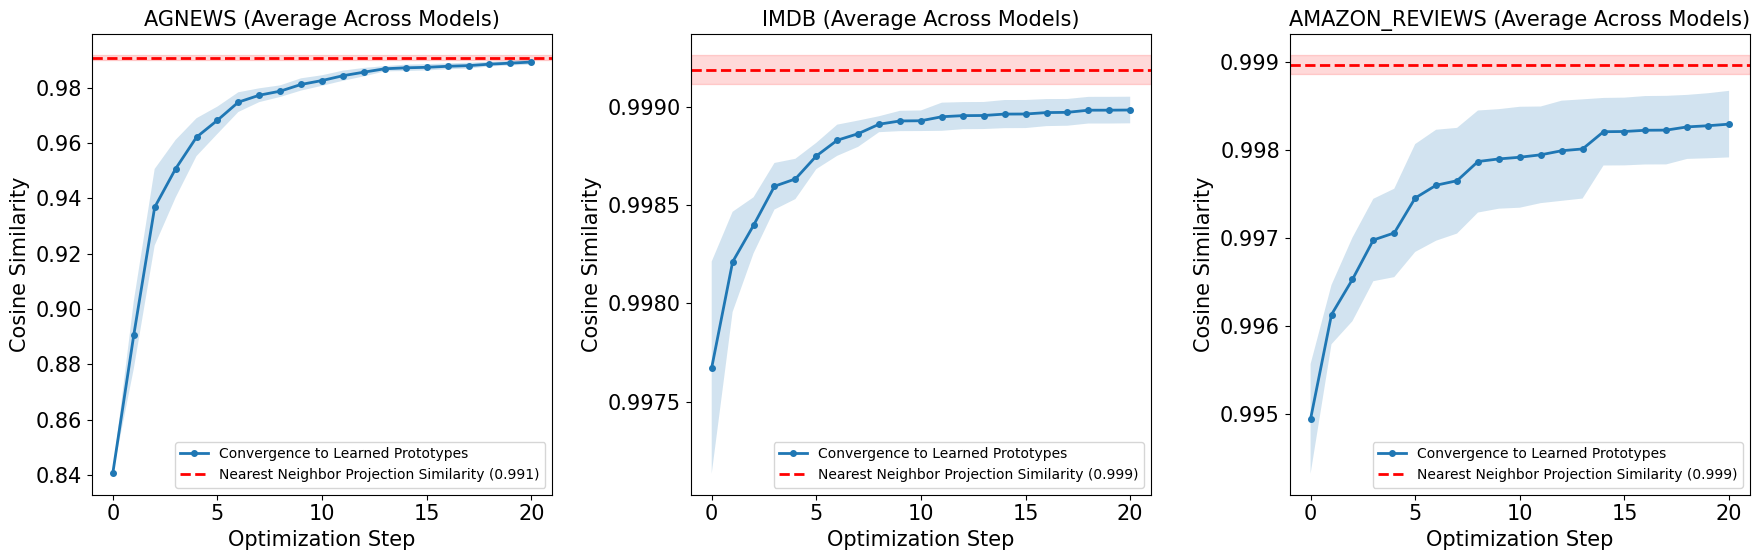


=== Creating all combinations plots (3x3) ===
Loaded agnews optimization data for seed 0 from ./data/optimization_exp_all_data_seed0_agnews.pickle
Loaded agnews optimization data for seed 1 from ./data/optimization_exp_all_data_seed1_agnews.pickle
Loaded agnews optimization data for seed 2 from ./data/optimization_exp_all_data_seed2_agnews.pickle
Loaded imdb/amazon_reviews optimization data for seed 0 from ./data/len_run/optimization_exp_all_data_seed0.pickle
Loaded imdb/amazon_reviews optimization data for seed 1 from ./data/len_run/optimization_exp_all_data_seed1.pickle
Loaded imdb/amazon_reviews optimization data for seed 2 from ./data/len_run/optimization_exp_all_data_seed2.pickle
Available seeds: [0, 1, 2]

Processing agnews-bert...
  Seed 0: Found 12 prototypes
  Seed 1: Found 12 prototypes
  Seed 2: Found 12 prototypes

Processing agnews-electra...
  Seed 0: Found 12 prototypes
  Seed 1: Found 12 prototypes
  Seed 2: Found 12 prototypes

Processing agnews-roberta...
  Seed 0: F

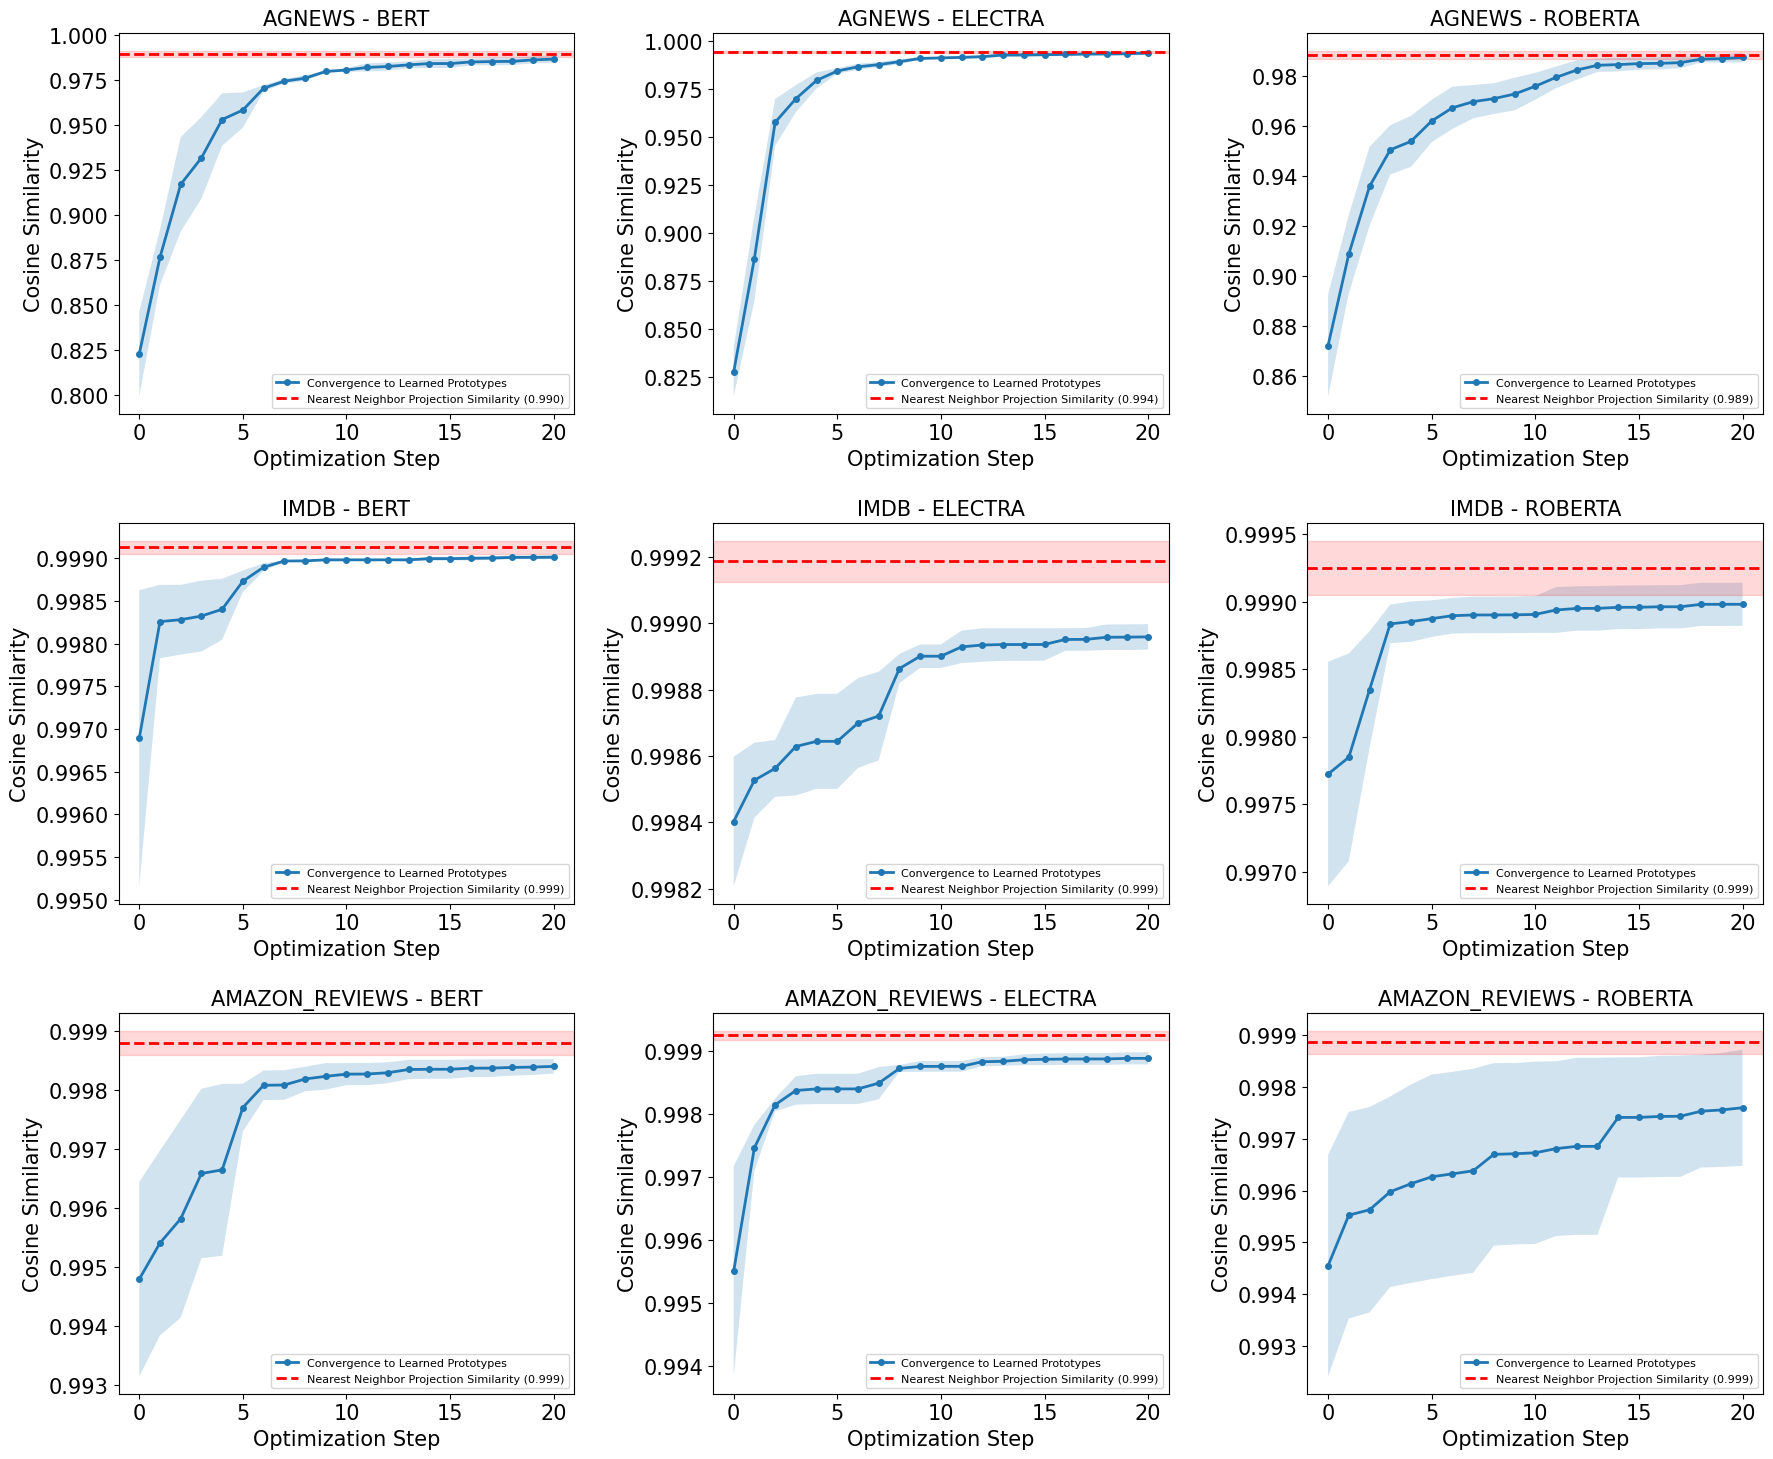

In [91]:
# #!/usr/bin/env python3
# """
# Multi-seed plotting script showing optimization convergence across multiple seeds.
# Plots mean ± standard error across seeds for cosine similarities.
# Y-axis scales dynamically per plot using standard error for zoomed-in view.
# """

# import pickle
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# import matplotlib.pyplot as plt

# # Make all fonts roughly double size
# plt.rcParams.update({
#     "font.size": 20,          # base font size
#     "axes.titlesize": 15,     # subplot titles
#     "axes.labelsize": 15,     # x and y labels
#     "xtick.labelsize": 15,    # x tick labels
#     "ytick.labelsize": 15,    # y tick labels
#     "legend.fontsize": 10     # legend
# })


# seeds = [0,1,2]  # Modify this list as needed

# def create_averaged_plots():
#     """Create plots averaged across models (1x3 plot for each dataset)"""
#     # Load data for all available seeds
#     all_data_by_seed = {}
#     available_seeds = []
    
#     for seed in seeds:
#         try:
#             with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
#                 all_data_by_seed[seed] = pickle.load(handle)
#                 available_seeds.append(seed)
#                 print(f"Loaded data for seed {seed}")
#         except FileNotFoundError:
#             print(f"Warning: Data file for seed {seed} not found, skipping")
#             continue
    
#     if not all_data_by_seed:
#         print("No data files found!")
#         return
    
#     print(f"Available seeds: {available_seeds}")
    
#     datasets = ['20newsgroups', 'imdb', 'amazon_reviews']
#     models = ['bert', 'electra', 'roberta']
    
#     # Create the 1x3 subplot (averaged across models)
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
#     os.makedirs('plots', exist_ok=True)
    
#     for i, dataset in enumerate(datasets):
#         ax = axes[i]
        
#         print(f"\nProcessing dataset {dataset} (averaging across models)...")
        
#         # Collect data across all models and seeds for this dataset
#         all_early_distances = []
#         all_optimization_curves = []  # List of mean curves (one per seed-model combination)
        
#         for seed in available_seeds:
#             all_data = all_data_by_seed[seed]
            
#             # Collect curves for this seed across all models
#             seed_curves = []
#             seed_early_distances = []
            
#             for model in models:
#                 key = f'{dataset}_{model}_latent_optim_3llms'
                
#                 if key not in all_data or not all_data[key]:
#                     print(f"  No data for {dataset}-{model} in seed {seed}")
#                     continue
                
#                 experiment_data = all_data[key]
#                 print(f"  Seed {seed}, {model}: Found {len(experiment_data)} prototypes")
                
#                 # Extract data
#                 early_distances = [float(proto['early_distance']) for proto in experiment_data]
#                 histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
#                 if not histories:
#                     continue
                
#                 max_len = max(len(h) for h in histories)
#                 padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
#                 similarities_array = np.array(padded, dtype=float)
#                 mean_for_seed_model = np.mean(similarities_array, axis=0)
                
#                 seed_curves.append(mean_for_seed_model)
#                 seed_early_distances.extend(early_distances)
            
#             if seed_curves:
#                 min_len = min(len(curve) for curve in seed_curves)
#                 truncated_curves = [curve[:min_len] for curve in seed_curves]
#                 seed_avg_curve = np.mean(truncated_curves, axis=0)
                
#                 all_optimization_curves.append(seed_avg_curve)
#                 all_early_distances.extend(seed_early_distances)
        
#         if not all_optimization_curves:
#             ax.text(0.5, 0.5, f'No data\n{dataset}', 
#                     ha='center', va='center', transform=ax.transAxes)
#             ax.set_title(f'{dataset.upper()}')
#             ax.set_xlabel('Iteration')
#             ax.set_ylabel('Cosine Similarity')
#             continue
        
#         # Find common length for curves
#         min_len = min(len(curve) for curve in all_optimization_curves)
#         truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
#         curves_array = np.array(truncated_curves)
        
#         mean_across_seeds = np.mean(curves_array, axis=0)
#         std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
#         sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
        
#         iterations = np.arange(min_len)
        
#         # Early baseline
#         early_mean = float(np.mean(all_early_distances))
#         early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
#         early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
        
#         # Plot
#         ax.plot(iterations, mean_across_seeds, linewidth=2, 
#                 label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
#         ax.fill_between(iterations, 
#                         mean_across_seeds - sem_across_seeds,
#                         mean_across_seeds + sem_across_seeds,
#                         alpha=0.2)
        
#         ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
#                    label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
#         ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
#                    alpha=0.15, color='red')
        
#         ax.set_xlabel('Optimization Step')
#         ax.set_ylabel('Cosine Similarity')
#         ax.set_title(f'{dataset.upper()} (Average Across Models)')
        
#         ax.legend(fontsize=10)
#         ax.grid(False)

#         ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
#         ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
#         pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
#         ax.set_ylim(ymin - pad, ymax + pad)
    
#     plt.tight_layout()
    
#     plot_path = 'plots/convergence_analysis_multiseed_averaged_models.pdf'
#     plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#     print(f"\nAveraged plot saved to: {plot_path}")
#     plt.show()

# def create_multi_seed_plots():
#     """Create original 3x3 plots showing all dataset-model combinations"""
#     all_data_by_seed = {}
#     available_seeds = []
    
#     for seed in seeds:
#         try:
#             with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
#                 all_data_by_seed[seed] = pickle.load(handle)
#                 available_seeds.append(seed)
#                 print(f"Loaded data for seed {seed}")
#         except FileNotFoundError:
#             print(f"Warning: Data file for seed {seed} not found, skipping")
#             continue
    
#     if not all_data_by_seed:
#         print("No data files found!")
#         return
    
#     print(f"Available seeds: {available_seeds}")
    
#     datasets = ['20newsgroups', 'imdb', 'amazon_reviews']
#     models = ['bert', 'electra', 'roberta']
    
#     # Create the 3x3 subplot
#     fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
#     os.makedirs('plots', exist_ok=True)
    
#     for i, dataset in enumerate(datasets):
#         for j, model in enumerate(models):
#             ax = axes[i, j]
            
#             print(f"\nProcessing {dataset}-{model}...")
            
#             all_early_distances = []
#             all_optimization_curves = []
            
#             for seed in available_seeds:
#                 key = f'{dataset}_{model}_latent_optim_3llms'
#                 all_data = all_data_by_seed[seed]
                
#                 if key not in all_data or not all_data[key]:
#                     print(f"  No data for {dataset}-{model} in seed {seed}")
#                     continue
                
#                 experiment_data = all_data[key]
#                 print(f"  Seed {seed}: Found {len(experiment_data)} prototypes")
                
#                 early_distances = [float(proto['early_distance']) for proto in experiment_data]
#                 histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
#                 if not histories:
#                     continue
                
#                 max_len = max(len(h) for h in histories)
#                 padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
#                 similarities_array = np.array(padded, dtype=float)
#                 mean_for_seed = np.mean(similarities_array, axis=0)
                
#                 all_early_distances.extend(early_distances)
#                 all_optimization_curves.append(mean_for_seed)
            
#             if not all_optimization_curves:
#                 ax.text(0.5, 0.5, f'No data\n{dataset}-{model}', 
#                         ha='center', va='center', transform=ax.transAxes)
#                 ax.set_title(f'{dataset.upper()} - {model.upper()}')
#                 ax.set_xlabel('Optimization Step')
#                 ax.set_ylabel('Cosine Similarity')
#                 continue
            
#             min_len = min(len(curve) for curve in all_optimization_curves)
#             truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
#             curves_array = np.array(truncated_curves)
            
#             mean_across_seeds = np.mean(curves_array, axis=0)
#             std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
#             sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            
#             iterations = np.arange(min_len)
            
#             early_mean = float(np.mean(all_early_distances))
#             early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
#             early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
            
#             ax.plot(iterations, mean_across_seeds, linewidth=2, 
#                     label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
#             ax.fill_between(iterations, 
#                             mean_across_seeds - sem_across_seeds,
#                             mean_across_seeds + sem_across_seeds,
#                             alpha=0.2)
            
#             ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
#                        label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
#             ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
#                        alpha=0.15, color='red')
            
#             ax.set_xlabel('Optimization Step')
#             ax.set_ylabel('Cosine Similarity')
#             ax.set_title(f'{dataset.upper()} - {model.upper()}')
            
#             ax.legend(fontsize=8)
#             ax.grid(False)

#             ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
#             ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
#             pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
#             ax.set_ylim(ymin - pad, ymax + pad)
    
#     plt.tight_layout()
    
#     plot_path = 'plots/convergence_analysis_multiseed_all_combinations.pdf'
#     plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#     print(f"\nAll combinations plot saved to: {plot_path}")
#     plt.show()

# if __name__ == "__main__":
#     print(f"Creating multi-seed convergence plots for seeds: {seeds}")
    
#     print("\n=== Creating averaged plots (across datasets) ===")
#     create_averaged_plots()
    
#     print("\n=== Creating all combinations plots (3x3) ===")
#     create_multi_seed_plots()


#!/usr/bin/env python3
"""
Multi-seed plotting script showing optimization convergence across multiple seeds.
Plots mean ± standard error across seeds for cosine similarities.
Y-axis scales dynamically per plot using standard error for zoomed-in view.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

import matplotlib.pyplot as plt

# Make all fonts roughly double size
plt.rcParams.update({
    "font.size": 20,          # base font size
    "axes.titlesize": 15,     # subplot titles
    "axes.labelsize": 15,     # x and y labels
    "xtick.labelsize": 15,    # x tick labels
    "ytick.labelsize": 15,    # y tick labels
    "legend.fontsize": 10     # legend
})

# Updated to handle different file locations and patterns
SEARCH_DIRS = ["./data", "./data/len_run"]  # agnews in data/, others in len_run/
DATASETS = ['agnews', 'imdb', 'amazon_reviews']  # Match first script
MODELS = ['bert', 'electra', 'roberta']
seeds = [0, 1, 2]  # Modify this list as needed

# Pattern to match optimization data files based on the actual filenames
# optimization_exp_all_data_seed{seed}_{dataset}.pickle
optim_fname_re = re.compile(
    r"^optimization_exp_all_data_seed(?P<seed>\d+)_(?P<dataset>.+?)\.pickle$"
)

def load_optimization_data():
    """Load optimization data from files in different directories with different patterns"""
    all_data_by_seed = {}
    available_seeds = []
    
    for seed in seeds:
        all_data_by_seed[seed] = {}
    
    # Handle agnews files in ./data/ with pattern: optimization_exp_all_data_seed{seed}_agnews.pickle
    data_dir = "./data"
    if os.path.exists(data_dir):
        for seed in seeds:
            file_pattern = f"optimization_exp_all_data_seed{seed}_agnews.pickle"
            file_path = os.path.join(data_dir, file_pattern)
            
            if os.path.exists(file_path):
                try:
                    with open(file_path, 'rb') as handle:
                        data = pickle.load(handle)
                        
                        if seed not in all_data_by_seed:
                            all_data_by_seed[seed] = {}
                        
                        # Store the data for this seed
                        all_data_by_seed[seed].update(data)
                        
                        if seed not in available_seeds:
                            available_seeds.append(seed)
                        print(f"Loaded agnews optimization data for seed {seed} from {file_path}")
                        
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")
    
    # Handle imdb and amazon_reviews files in ./data/len_run/ with pattern: optimization_exp_all_data_seed{seed}.pickle
    len_run_dir = "./data/len_run"
    if os.path.exists(len_run_dir):
        for seed in seeds:
            file_pattern = f"optimization_exp_all_data_seed{seed}.pickle"
            file_path = os.path.join(len_run_dir, file_pattern)
            
            if os.path.exists(file_path):
                try:
                    with open(file_path, 'rb') as handle:
                        data = pickle.load(handle)
                        
                        if seed not in all_data_by_seed:
                            all_data_by_seed[seed] = {}
                        
                        # Store the data for this seed (should contain imdb and amazon_reviews)
                        all_data_by_seed[seed].update(data)
                        
                        if seed not in available_seeds:
                            available_seeds.append(seed)
                        print(f"Loaded imdb/amazon_reviews optimization data for seed {seed} from {file_path}")
                        
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")
    
    return all_data_by_seed, available_seeds

def create_averaged_plots():
    """Create plots averaged across models (1x3 plot for each dataset)"""
    # Load data for all available seeds
    all_data_by_seed, available_seeds = load_optimization_data()
    
    if not all_data_by_seed or not available_seeds:
        print("No optimization data files found!")
        print(f"Searched in directories: {SEARCH_DIRS}")
        print("Expected file patterns:")
        print("  - optimization_exp_all_data_seed{seed}_{dataset}.pickle")
        print(f"  - For datasets: {DATASETS}")
        print(f"  - For seeds: {seeds}")
        return
    
    print(f"Available seeds: {available_seeds}")
    
    datasets = DATASETS  # Use the updated dataset list
    models = MODELS
    
    # Create the 1x3 subplot (averaged across models)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    os.makedirs('plots', exist_ok=True)
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        
        print(f"\nProcessing dataset {dataset} (averaging across models)...")
        
        # Collect data across all models and seeds for this dataset
        all_early_distances = []
        all_optimization_curves = []  # List of mean curves (one per seed-model combination)
        
        for seed in available_seeds:
            all_data = all_data_by_seed[seed]
            
            # Collect curves for this seed across all models
            seed_curves = []
            seed_early_distances = []
            
            for model in models:
                key = f'{dataset}_{model}_latent_optim_3llms'
                
                if key not in all_data or not all_data[key]:
                    print(f"  No data for {dataset}-{model} in seed {seed}")
                    continue
                
                experiment_data = all_data[key]
                print(f"  Seed {seed}, {model}: Found {len(experiment_data)} prototypes")
                
                # Extract data
                early_distances = [float(proto['early_distance']) for proto in experiment_data]
                histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
                if not histories:
                    continue
                
                max_len = max(len(h) for h in histories)
                padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                similarities_array = np.array(padded, dtype=float)
                mean_for_seed_model = np.mean(similarities_array, axis=0)
                
                seed_curves.append(mean_for_seed_model)
                seed_early_distances.extend(early_distances)
            
            if seed_curves:
                min_len = min(len(curve) for curve in seed_curves)
                truncated_curves = [curve[:min_len] for curve in seed_curves]
                seed_avg_curve = np.mean(truncated_curves, axis=0)
                
                all_optimization_curves.append(seed_avg_curve)
                all_early_distances.extend(seed_early_distances)
        
        if not all_optimization_curves:
            ax.text(0.5, 0.5, f'No data\n{dataset}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dataset.upper()}')
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Cosine Similarity')
            continue
        
        # Find common length for curves
        min_len = min(len(curve) for curve in all_optimization_curves)
        truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
        curves_array = np.array(truncated_curves)
        
        mean_across_seeds = np.mean(curves_array, axis=0)
        std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
        sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
        
        iterations = np.arange(min_len)
        
        # Early baseline
        early_mean = float(np.mean(all_early_distances))
        early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
        early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
        
        # Plot
        ax.plot(iterations, mean_across_seeds, linewidth=2, 
                label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
        ax.fill_between(iterations, 
                        mean_across_seeds - sem_across_seeds,
                        mean_across_seeds + sem_across_seeds,
                        alpha=0.2)
        
        ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                   label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
        ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                   alpha=0.15, color='red')
        
        ax.set_xlabel('Optimization Step')
        ax.set_ylabel('Cosine Similarity')
        ax.set_title(f'{dataset.upper()} (Average Across Models)')
        
        ax.legend(fontsize=10)
        ax.grid(False)

        ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
        ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
        pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - pad, ymax + pad)
    
    plt.tight_layout()
    
    plot_path = 'plots/convergence_analysis_multiseed_averaged_models.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nAveraged plot saved to: {plot_path}")
    plt.show()

def create_multi_seed_plots():
    """Create original 3x3 plots showing all dataset-model combinations"""
    all_data_by_seed, available_seeds = load_optimization_data()
    
    if not all_data_by_seed or not available_seeds:
        print("No optimization data files found!")
        print(f"Searched in directories: {SEARCH_DIRS}")
        print("Expected file patterns:")
        print("  - optimization_exp_all_data_seed{seed}_{dataset}.pickle")
        print(f"  - For datasets: {DATASETS}")
        print(f"  - For seeds: {seeds}")
        return
    
    print(f"Available seeds: {available_seeds}")
    
    datasets = DATASETS  # Use the updated dataset list
    models = MODELS
    
    # Create the 3x3 subplot
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    os.makedirs('plots', exist_ok=True)
    
    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):
            ax = axes[i, j]
            
            print(f"\nProcessing {dataset}-{model}...")
            
            all_early_distances = []
            all_optimization_curves = []
            
            for seed in available_seeds:
                key = f'{dataset}_{model}_latent_optim_3llms'
                all_data = all_data_by_seed[seed]
                
                if key not in all_data or not all_data[key]:
                    print(f"  No data for {dataset}-{model} in seed {seed}")
                    continue
                
                experiment_data = all_data[key]
                print(f"  Seed {seed}: Found {len(experiment_data)} prototypes")
                
                early_distances = [float(proto['early_distance']) for proto in experiment_data]
                histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
                if not histories:
                    continue
                
                max_len = max(len(h) for h in histories)
                padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                similarities_array = np.array(padded, dtype=float)
                mean_for_seed = np.mean(similarities_array, axis=0)
                
                all_early_distances.extend(early_distances)
                all_optimization_curves.append(mean_for_seed)
            
            if not all_optimization_curves:
                ax.text(0.5, 0.5, f'No data\n{dataset}-{model}', 
                        ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{dataset.upper()} - {model.upper()}')
                ax.set_xlabel('Optimization Step')
                ax.set_ylabel('Cosine Similarity')
                continue
            
            min_len = min(len(curve) for curve in all_optimization_curves)
            truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
            curves_array = np.array(truncated_curves)
            
            mean_across_seeds = np.mean(curves_array, axis=0)
            std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            
            iterations = np.arange(min_len)
            
            early_mean = float(np.mean(all_early_distances))
            early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
            early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
            
            ax.plot(iterations, mean_across_seeds, linewidth=2, 
                    label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
            ax.fill_between(iterations, 
                            mean_across_seeds - sem_across_seeds,
                            mean_across_seeds + sem_across_seeds,
                            alpha=0.2)
            
            ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                       label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
            ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                       alpha=0.15, color='red')
            
            ax.set_xlabel('Optimization Step')
            ax.set_ylabel('Cosine Similarity')
            ax.set_title(f'{dataset.upper()} - {model.upper()}')
            
            ax.legend(fontsize=8)
            ax.grid(False)

            ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
            ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
            pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
    
    plt.tight_layout()
    
    plot_path = 'plots/convergence_analysis_multiseed_all_combinations.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nAll combinations plot saved to: {plot_path}")
    plt.show()

if __name__ == "__main__":
    print(f"Creating multi-seed convergence plots for seeds: {seeds}")
    print(f"Searching in directories: {SEARCH_DIRS}")
    print(f"Using datasets: {DATASETS}")
    print(f"Looking for files: optimization_exp_all_data_seed{{seed}}_{{dataset}}.pickle")
    
    print("\n=== Creating averaged plots (across datasets) ===")
    create_averaged_plots()
    
    print("\n=== Creating all combinations plots (3x3) ===")
    create_multi_seed_plots()

In [80]:
# #!/usr/bin/env python3
# """
# Extract and display summary results from the experiment data in table format.
# Shows accuracy metrics (as percentages), precision, recall, F1 scores, and cosine similarity measurements across multiple seeds.
# Reports mean ± standard error for each metric.
# Includes statistical significance testing between Stage A and Stage B results.
# Includes average accuracy changes from Base to Stage A and Stage B.
# """

# import pickle
# import pandas as pd
# import numpy as np
# from scipy import stats

# seeds = [0,1,2,3,4,5]  # Modify this list as needed

# def extract_summary_data():
#     # Load data for all available seeds
#     all_data_by_seed = {}
#     for seed in seeds:
#         try:
#             with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
#                 all_data_by_seed[seed] = pickle.load(handle)
#                 print(f"Loaded data for seed {seed}")
#         except FileNotFoundError:
#             print(f"Warning: Data file for seed {seed} not found, skipping")
#             continue
    
#     if not all_data_by_seed:
#         print("No data files found!")
#         return []
    
#     datasets = ['imdb', 'amazon_reviews', '20newsgroups']
#     models = ['bert', 'electra', 'roberta']
    
#     results = []
    
#     for dataset in datasets:
#         for model in models:
#             # Collect metrics across all available seeds for this dataset/model combination
#             metrics_across_seeds = {
#                 'base_acc': [],
#                 'stageA_acc': [],
#                 'stageB_acc': [],
#                 'base_f1': [],
#                 'stageA_f1': [],
#                 'stageB_f1': [],
#                 'base_precision': [],
#                 'stageA_precision': [],
#                 'stageB_precision': [],
#                 'base_recall': [],
#                 'stageA_recall': [],
#                 'stageB_recall': [],
#                 'cos_proto_to_train': [],
#                 'cos_optimized_to_proto': []
#             }
            
#             for seed in seeds:
#                 if seed not in all_data_by_seed:
#                     continue
                
#                 all_data = all_data_by_seed[seed]
#                 summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
                
#                 if summary_key in all_data:
#                     summary = all_data[summary_key]
                    
#                     # Extract accuracy metrics
#                     base_acc = summary.get('base_metrics', {}).get('accuracy', None)
#                     if base_acc is not None:
#                         metrics_across_seeds['base_acc'].append(base_acc)
                    
#                     stageA_acc = summary.get('stageA_metrics_optimized_text_latents', {}).get('accuracy', None)
#                     if stageA_acc is not None:
#                         metrics_across_seeds['stageA_acc'].append(stageA_acc)
                    
#                     stageB_acc = summary.get('stageB_metrics_projected', {}).get('accuracy', None)
#                     if stageB_acc is not None:
#                         metrics_across_seeds['stageB_acc'].append(stageB_acc)
                    
#                     # Extract F1 scores
#                     base_f1 = summary.get('base_metrics', {}).get('macro', {}).get('f1', None)
#                     if base_f1 is not None:
#                         metrics_across_seeds['base_f1'].append(base_f1)
                    
#                     stageA_f1 = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('f1', None)
#                     if stageA_f1 is not None:
#                         metrics_across_seeds['stageA_f1'].append(stageA_f1)
                    
#                     stageB_f1 = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('f1', None)
#                     if stageB_f1 is not None:
#                         metrics_across_seeds['stageB_f1'].append(stageB_f1)
                    
#                     # Extract precision scores
#                     base_precision = summary.get('base_metrics', {}).get('macro', {}).get('precision', None)
#                     if base_precision is not None:
#                         metrics_across_seeds['base_precision'].append(base_precision)
                    
#                     stageA_precision = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('precision', None)
#                     if stageA_precision is not None:
#                         metrics_across_seeds['stageA_precision'].append(stageA_precision)
                    
#                     stageB_precision = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('precision', None)
#                     if stageB_precision is not None:
#                         metrics_across_seeds['stageB_precision'].append(stageB_precision)
                    
#                     # Extract recall scores
#                     base_recall = summary.get('base_metrics', {}).get('macro', {}).get('recall', None)
#                     if base_recall is not None:
#                         metrics_across_seeds['base_recall'].append(base_recall)
                    
#                     stageA_recall = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('recall', None)
#                     if stageA_recall is not None:
#                         metrics_across_seeds['stageA_recall'].append(stageA_recall)
                    
#                     stageB_recall = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('recall', None)
#                     if stageB_recall is not None:
#                         metrics_across_seeds['stageB_recall'].append(stageB_recall)
                    
#                     # Extract cosine similarity metrics
#                     cos_proto_to_train = summary.get('avg_cosine_proto_to_nearest_train', None)
#                     if cos_proto_to_train is not None:
#                         metrics_across_seeds['cos_proto_to_train'].append(cos_proto_to_train)
                    
#                     cos_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', None)
#                     if cos_optimized_to_proto is not None:
#                         metrics_across_seeds['cos_optimized_to_proto'].append(cos_optimized_to_proto)
#                 else:
#                     print(f"Warning: Summary key '{summary_key}' not found for seed {seed}")
            
#             # Compute mean and standard error for each metric
#             def compute_stats(values):
#                 if len(values) == 0:
#                     return None, None, 0
#                 elif len(values) == 1:
#                     return values[0], 0.0, 1
#                 else:
#                     mean = np.mean(values)
#                     std_err = np.std(values, ddof=1) / np.sqrt(len(values))
#                     return mean, std_err, len(values)
            
#             # Apply to all metrics
#             base_acc_mean, base_acc_se, base_acc_n = compute_stats(metrics_across_seeds['base_acc'])
#             stageA_acc_mean, stageA_acc_se, stageA_acc_n = compute_stats(metrics_across_seeds['stageA_acc'])
#             stageB_acc_mean, stageB_acc_se, stageB_acc_n = compute_stats(metrics_across_seeds['stageB_acc'])
            
#             base_f1_mean, base_f1_se, base_f1_n = compute_stats(metrics_across_seeds['base_f1'])
#             stageA_f1_mean, stageA_f1_se, stageA_f1_n = compute_stats(metrics_across_seeds['stageA_f1'])
#             stageB_f1_mean, stageB_f1_se, stageB_f1_n = compute_stats(metrics_across_seeds['stageB_f1'])
            
#             base_precision_mean, base_precision_se, base_precision_n = compute_stats(metrics_across_seeds['base_precision'])
#             stageA_precision_mean, stageA_precision_se, stageA_precision_n = compute_stats(metrics_across_seeds['stageA_precision'])
#             stageB_precision_mean, stageB_precision_se, stageB_precision_n = compute_stats(metrics_across_seeds['stageB_precision'])
            
#             base_recall_mean, base_recall_se, base_recall_n = compute_stats(metrics_across_seeds['base_recall'])
#             stageA_recall_mean, stageA_recall_se, stageA_recall_n = compute_stats(metrics_across_seeds['stageA_recall'])
#             stageB_recall_mean, stageB_recall_se, stageB_recall_n = compute_stats(metrics_across_seeds['stageB_recall'])
            
#             cos_proto_mean, cos_proto_se, cos_proto_n = compute_stats(metrics_across_seeds['cos_proto_to_train'])
#             cos_opt_mean, cos_opt_se, cos_opt_n = compute_stats(metrics_across_seeds['cos_optimized_to_proto'])
            
#             # Calculate accuracy changes (as percentages)
#             acc_change_base_to_A = None
#             acc_change_base_to_B = None
#             if base_acc_mean is not None and stageA_acc_mean is not None:
#                 acc_change_base_to_A = (stageA_acc_mean - base_acc_mean) * 100  # Convert to percentage points
#             if base_acc_mean is not None and stageB_acc_mean is not None:
#                 acc_change_base_to_B = (stageB_acc_mean - base_acc_mean) * 100  # Convert to percentage points
            
#             # Statistical significance test between Stage A and Stage B accuracies
#             pvalue_acc_A_vs_B = None
#             if (len(metrics_across_seeds['stageA_acc']) >= 2 and 
#                 len(metrics_across_seeds['stageB_acc']) >= 2 and
#                 len(metrics_across_seeds['stageA_acc']) == len(metrics_across_seeds['stageB_acc'])):
#                 try:
#                     # Paired t-test between Stage A and Stage B accuracies
#                     stat, p_val = stats.ttest_rel(metrics_across_seeds['stageA_acc'], 
#                                                   metrics_across_seeds['stageB_acc'])
#                     pvalue_acc_A_vs_B = p_val
#                 except:
#                     pvalue_acc_A_vs_B = None
            
#             results.append({
#                 'Dataset': dataset.upper(),
#                 'Model': model.upper(),
#                 'Base_Acc_Mean': base_acc_mean,
#                 'Base_Acc_SE': base_acc_se,
#                 'Base_Acc_N': base_acc_n,
#                 'StageA_Acc_Mean': stageA_acc_mean,
#                 'StageA_Acc_SE': stageA_acc_se,
#                 'StageA_Acc_N': stageA_acc_n,
#                 'StageB_Acc_Mean': stageB_acc_mean,
#                 'StageB_Acc_SE': stageB_acc_se,
#                 'StageB_Acc_N': stageB_acc_n,
#                 'Acc_Change_Base_to_A': acc_change_base_to_A,
#                 'Acc_Change_Base_to_B': acc_change_base_to_B,
#                 'PValue_A_vs_B_Acc': pvalue_acc_A_vs_B,
#                 'Base_F1_Mean': base_f1_mean,
#                 'Base_F1_SE': base_f1_se,
#                 'StageA_F1_Mean': stageA_f1_mean,
#                 'StageA_F1_SE': stageA_f1_se,
#                 'StageB_F1_Mean': stageB_f1_mean,
#                 'StageB_F1_SE': stageB_f1_se,
#                 'Base_Precision_Mean': base_precision_mean,
#                 'Base_Precision_SE': base_precision_se,
#                 'StageA_Precision_Mean': stageA_precision_mean,
#                 'StageA_Precision_SE': stageA_precision_se,
#                 'StageB_Precision_Mean': stageB_precision_mean,
#                 'StageB_Precision_SE': stageB_precision_se,
#                 'Base_Recall_Mean': base_recall_mean,
#                 'Base_Recall_SE': base_recall_se,
#                 'StageA_Recall_Mean': stageA_recall_mean,
#                 'StageA_Recall_SE': stageA_recall_se,
#                 'StageB_Recall_Mean': stageB_recall_mean,
#                 'StageB_Recall_SE': stageB_recall_se,
#                 'Cos_Proto_Mean': cos_proto_mean,
#                 'Cos_Proto_SE': cos_proto_se,
#                 'Cos_Opt_Mean': cos_opt_mean,
#                 'Cos_Opt_SE': cos_opt_se,
#             })
    
#     return results

# def format_mean_se(mean, se, n, as_percentage=False):
#     """Format mean ± standard error with sample size"""
#     if mean is None:
#         return "N/A"
#     elif se is None or se == 0:
#         if as_percentage:
#             return f"{mean*100:.2f}% (n={n})"
#         else:
#             return f"{mean:.4f} (n={n})"
#     else:
#         if as_percentage:
#             return f"{mean*100:.2f}±{se*100:.2f}% (n={n})"
#         else:
#             return f"{mean:.4f}±{se:.4f} (n={n})"

# def format_pvalue(pvalue):
#     """Format p-value with appropriate precision"""
#     if pvalue is None:
#         return "N/A"
#     elif pvalue < 0.001:
#         return "<0.001"
#     else:
#         return f"{pvalue:.3f}"

# def format_change(change):
#     """Format accuracy change in percentage points"""
#     if change is None:
#         return "N/A"
#     else:
#         return f"{change:+.2f}pp"

# def display_results_table(results):
#     df = pd.DataFrame(results)
    
#     print("="*180)
#     print("EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)")
#     print("="*180)
    
#     print("\nACCURACY RESULTS (as percentages)")
#     print("-" * 160)
#     print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20} {'ΔA':<10} {'ΔB':<10} {'p-value':<10}")
#     print("-" * 160)
    
#     for _, row in df.iterrows():
#         base_acc = format_mean_se(row['Base_Acc_Mean'], row['Base_Acc_SE'], row['Base_Acc_N'], as_percentage=True)
#         stageA_acc = format_mean_se(row['StageA_Acc_Mean'], row['StageA_Acc_SE'], row['StageA_Acc_N'], as_percentage=True)
#         stageB_acc = format_mean_se(row['StageB_Acc_Mean'], row['StageB_Acc_SE'], row['StageB_Acc_N'], as_percentage=True)
#         change_A = format_change(row['Acc_Change_Base_to_A'])
#         change_B = format_change(row['Acc_Change_Base_to_B'])
#         pvalue = format_pvalue(row['PValue_A_vs_B_Acc'])
        
#         print(f"{row['Dataset']:<12} {row['Model']:<8} {base_acc:<20} {stageA_acc:<20} {stageB_acc:<20} {change_A:<10} {change_B:<10} {pvalue:<10}")
    
#     print("\nMACRO F1 SCORES")
#     print("-" * 100)
#     print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
#     print("-" * 100)
    
#     for _, row in df.iterrows():
#         base_f1 = format_mean_se(row['Base_F1_Mean'], row['Base_F1_SE'], row['Base_Acc_N'])
#         stageA_f1 = format_mean_se(row['StageA_F1_Mean'], row['StageA_F1_SE'], row['StageA_Acc_N'])
#         stageB_f1 = format_mean_se(row['StageB_F1_Mean'], row['StageB_F1_SE'], row['StageB_Acc_N'])
        
#         print(f"{row['Dataset']:<12} {row['Model']:<8} {base_f1:<20} {stageA_f1:<20} {stageB_f1:<20}")
    
#     print("\nMACRO PRECISION SCORES")
#     print("-" * 100)
#     print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
#     print("-" * 100)
    
#     for _, row in df.iterrows():
#         base_precision = format_mean_se(row['Base_Precision_Mean'], row['Base_Precision_SE'], row['Base_Acc_N'])
#         stageA_precision = format_mean_se(row['StageA_Precision_Mean'], row['StageA_Precision_SE'], row['StageA_Acc_N'])
#         stageB_precision = format_mean_se(row['StageB_Precision_Mean'], row['StageB_Precision_SE'], row['StageB_Acc_N'])
        
#         print(f"{row['Dataset']:<12} {row['Model']:<8} {base_precision:<20} {stageA_precision:<20} {stageB_precision:<20}")
    
#     print("\nMACRO RECALL SCORES")
#     print("-" * 100)
#     print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
#     print("-" * 100)
    
#     for _, row in df.iterrows():
#         base_recall = format_mean_se(row['Base_Recall_Mean'], row['Base_Recall_SE'], row['Base_Acc_N'])
#         stageA_recall = format_mean_se(row['StageA_Recall_Mean'], row['StageA_Recall_SE'], row['StageA_Acc_N'])
#         stageB_recall = format_mean_se(row['StageB_Recall_Mean'], row['StageB_Recall_SE'], row['StageB_Acc_N'])
        
#         print(f"{row['Dataset']:<12} {row['Model']:<8} {base_recall:<20} {stageA_recall:<20} {stageB_recall:<20}")
    
#     print("\nCOSINE SIMILARITY TO BLACK BOX PROTOTYPES")
#     print("-" * 90)
#     print(f"{'Dataset':<12} {'Model':<8} {'Proto->Train':<25} {'Opt->Proto':<25}")
#     print("-" * 90)
    
#     for _, row in df.iterrows():
#         cos1 = format_mean_se(row['Cos_Proto_Mean'], row['Cos_Proto_SE'], row['Base_Acc_N'])
#         cos2 = format_mean_se(row['Cos_Opt_Mean'], row['Cos_Opt_SE'], row['Base_Acc_N'])
        
#         print(f"{row['Dataset']:<12} {row['Model']:<8} {cos1:<25} {cos2:<25}")
    
#     # Summary statistics
#     print("\nSUMMARY STATISTICS")
#     print("-" * 70)
    
#     # Count significant differences (p < 0.05)
#     valid_pvalues = [row['PValue_A_vs_B_Acc'] for _, row in df.iterrows() 
#                      if row['PValue_A_vs_B_Acc'] is not None]
#     significant_diffs = sum(1 for p in valid_pvalues if p < 0.05)
    
#     print(f"Significant differences (p<0.05) between Stage A and B: {significant_diffs}/{len(valid_pvalues)} combinations")
    
#     # Average accuracy changes
#     print(f"\nACCURACY CHANGES (Average across all combinations):")
#     print("-" * 50)
    
#     valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
#                        if row['Acc_Change_Base_to_A'] is not None]
#     valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
#                        if row['Acc_Change_Base_to_B'] is not None]
    
#     if valid_changes_A:
#         avg_change_A = np.mean(valid_changes_A)
#         se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
#         print(f"Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points (n={len(valid_changes_A)})")
    
#     if valid_changes_B:
#         avg_change_B = np.mean(valid_changes_B)
#         se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
#         print(f"Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points (n={len(valid_changes_B)})")
    
#     # Compare the two improvements
#     if valid_changes_A and valid_changes_B and len(valid_changes_A) == len(valid_changes_B):
#         try:
#             # Paired t-test between the two types of improvements
#             stat, p_val = stats.ttest_rel(valid_changes_A, valid_changes_B)
#             print(f"Comparison: Stage A vs Stage B improvements, p-value = {p_val:.4f}")
#             if avg_change_A > avg_change_B:
#                 print(f"Stage A shows {avg_change_A - avg_change_B:.2f}pp greater improvement on average")
#             else:
#                 print(f"Stage B shows {avg_change_B - avg_change_A:.2f}pp greater improvement on average")
#         except:
#             pass
    
#     # Count how many times Stage A > Stage B for each metric (based on mean values)
#     print(f"\nStage A vs Stage B Performance (based on mean values):")
#     print("-" * 50)
    
#     metrics_comparison = {
#         'Accuracy': ('StageA_Acc_Mean', 'StageB_Acc_Mean'),
#         'F1 Score': ('StageA_F1_Mean', 'StageB_F1_Mean'),
#         'Precision': ('StageA_Precision_Mean', 'StageB_Precision_Mean'),
#         'Recall': ('StageA_Recall_Mean', 'StageB_Recall_Mean')
#     }
    
#     for metric_name, (stageA_col, stageB_col) in metrics_comparison.items():
#         # Count valid comparisons
#         valid_comparisons = []
#         for _, row in df.iterrows():
#             if row[stageA_col] is not None and row[stageB_col] is not None:
#                 valid_comparisons.append((row[stageA_col], row[stageB_col]))
        
#         if valid_comparisons:
#             stage_a_wins = sum(1 for a, b in valid_comparisons if a > b)
#             stage_b_wins = sum(1 for a, b in valid_comparisons if b > a)
#             ties = sum(1 for a, b in valid_comparisons if a == b)
#             total = len(valid_comparisons)
            
#             print(f"{metric_name:<12}: Stage A wins: {stage_a_wins}/{total}, Stage B wins: {stage_b_wins}/{total}, Ties: {ties}/{total}")
    
#     # Show combinations with significant differences
#     if significant_diffs > 0:
#         print(f"\nSignificant differences found in:")
#         for _, row in df.iterrows():
#             if row['PValue_A_vs_B_Acc'] is not None and row['PValue_A_vs_B_Acc'] < 0.05:
#                 direction = "A > B" if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean'] else "B > A"
#                 print(f"  {row['Dataset']}-{row['Model']}: p={row['PValue_A_vs_B_Acc']:.4f} ({direction})")
    
#     return df

# def save_results_table(df):
#     # Save as CSV for easy analysis
#     df.to_csv('plots/experiment_results_summary_multiseed.csv', index=False)
#     print(f"\nResults saved to: plots/experiment_results_summary_multiseed.csv")
    
#     # Create a formatted text report
#     with open('plots/experiment_results_report_multiseed.txt', 'w') as f:
#         f.write("EXPERIMENT RESULTS SUMMARY (Multi-seed)\n")
#         f.write("="*50 + "\n\n")
        
#         f.write("ACCURACY RESULTS (as percentages, Mean ± SE):\n")
#         f.write("-"*40 + "\n")
        
#         for _, row in df.iterrows():
#             if row['Base_Acc_Mean'] is not None:
#                 f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
#                        f"Base: {row['Base_Acc_Mean']*100:.2f}±{row['Base_Acc_SE']*100:.2f}%, "
#                        f"A: {row['StageA_Acc_Mean']*100:.2f}±{row['StageA_Acc_SE']*100:.2f}%, "
#                        f"B: {row['StageB_Acc_Mean']*100:.2f}±{row['StageB_Acc_SE']*100:.2f}%")
#                 if row['Acc_Change_Base_to_A'] is not None:
#                     f.write(f", ΔA: {row['Acc_Change_Base_to_A']:+.2f}pp")
#                 if row['Acc_Change_Base_to_B'] is not None:
#                     f.write(f", ΔB: {row['Acc_Change_Base_to_B']:+.2f}pp")
#                 if row['PValue_A_vs_B_Acc'] is not None:
#                     f.write(f", p(A vs B): {row['PValue_A_vs_B_Acc']:.4f}")
#                 f.write("\n")
        
#         f.write(f"\nPRECISION & RECALL (Mean ± SE):\n")
#         f.write("-"*40 + "\n")
        
#         for _, row in df.iterrows():
#             if row['Base_Precision_Mean'] is not None:
#                 f.write(f"{row['Dataset']:<12} {row['Model']:<8} Precision - "
#                        f"Base: {row['Base_Precision_Mean']:.4f}±{row['Base_Precision_SE']:.4f}, "
#                        f"A: {row['StageA_Precision_Mean']:.4f}±{row['StageA_Precision_SE']:.4f}, "
#                        f"B: {row['StageB_Precision_Mean']:.4f}±{row['StageB_Precision_SE']:.4f}\n")
#             if row['Base_Recall_Mean'] is not None:
#                 f.write(f"{row['Dataset']:<12} {row['Model']:<8} Recall - "
#                        f"Base: {row['Base_Recall_Mean']:.4f}±{row['Base_Recall_SE']:.4f}, "
#                        f"A: {row['StageA_Recall_Mean']:.4f}±{row['StageA_Recall_SE']:.4f}, "
#                        f"B: {row['StageB_Recall_Mean']:.4f}±{row['StageB_Recall_SE']:.4f}\n")
        
#         f.write(f"\nCOSINE SIMILARITIES (Mean ± SE):\n")
#         f.write("-"*40 + "\n")
        
#         for _, row in df.iterrows():
#             if row['Cos_Proto_Mean'] is not None:
#                 f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
#                        f"Proto->Train: {row['Cos_Proto_Mean']:.4f}±{row['Cos_Proto_SE']:.4f}, "
#                        f"Opt->Proto: {row['Cos_Opt_Mean']:.4f}±{row['Cos_Opt_SE']:.4f}\n")
        
#         # Add accuracy change summary
#         valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
#                            if row['Acc_Change_Base_to_A'] is not None]
#         valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
#                            if row['Acc_Change_Base_to_B'] is not None]
        
#         f.write(f"\nACCURACY CHANGE SUMMARY:\n")
#         f.write("-"*30 + "\n")
        
#         if valid_changes_A:
#             avg_change_A = np.mean(valid_changes_A)
#             se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
#             f.write(f"Average Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points\n")
        
#         if valid_changes_B:
#             avg_change_B = np.mean(valid_changes_B)
#             se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
#             f.write(f"Average Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points\n")
    
#     print(f"Text report saved to: plots/experiment_results_report_multiseed.txt")

# def main():
#     print(f"Extracting summary data from experiment results across seeds: {seeds}")
    
#     results = extract_summary_data()
    
#     if not results:
#         print("No summary data found!")
#         return
    
#     print(f"Found summary data for {len(results)} dataset/model combinations\n")
    
#     df = display_results_table(results)
#     save_results_table(df)
    
#     print("\n" + "="*180)
#     print("Legend:")
#     print("• Base: Original network accuracy/precision/recall/F1")
#     print("• Stage A: After optimizing prototypes with text (pre-projection)")
#     print("• Stage B: After projecting to nearest training embeddings (post-projection)")
#     print("• ΔA/ΔB: Accuracy change from Base to Stage A/B in percentage points (pp)")
#     print("• p-value: Paired t-test p-value comparing Stage A vs Stage B accuracies")
#     print("• Proto->Train: Cosine similarity between learned prototypes and nearest training embeddings")
#     print("• Opt->Proto: Cosine similarity between optimized text prototypes and original learned prototypes")
#     print("• Format: Mean±SE (n=sample_size) for accuracy as %, others as decimals")
#     print(f"• Seeds analyzed: {seeds}")
#     print("• Significance level: p < 0.05")

# if __name__ == "__main__":
#     main()

In [92]:
#!/usr/bin/env python3
"""
Extract and display summary results from the experiment data in table format.
Shows accuracy metrics (as percentages), precision, recall, F1 scores, and cosine similarity measurements across multiple seeds.
Reports mean ± standard error for each metric.
Includes statistical significance testing between Stage A and Stage B results.
Includes average accuracy changes from Base to Stage A and Stage B.
NEW: Includes prototype text length analysis across seeds.
"""

import pickle
import pandas as pd
import numpy as np
from scipy import stats

seeds = [0,1,2]  # Modify this list as needed

def extract_summary_data():
    # Load data for all available seeds
    all_data_by_seed = {}
    for seed in seeds:
        try:
            with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
                all_data_by_seed[seed] = pickle.load(handle)
                print(f"Loaded data for seed {seed}")
        except FileNotFoundError:
            print(f"Warning: Data file for seed {seed} not found, skipping")
            continue
    
    if not all_data_by_seed:
        print("No data files found!")
        return []
    
    datasets = ['imdb', 'amazon_reviews', 'agnews']
    models = ['bert', 'electra', 'roberta']
    
    results = []
    
    for dataset in datasets:
        for model in models:
            # Collect metrics across all available seeds for this dataset/model combination
            metrics_across_seeds = {
                'base_acc': [],
                'stageA_acc': [],
                'stageB_acc': [],
                'base_f1': [],
                'stageA_f1': [],
                'stageB_f1': [],
                'base_precision': [],
                'stageA_precision': [],
                'stageB_precision': [],
                'base_recall': [],
                'stageA_recall': [],
                'stageB_recall': [],
                'cos_proto_to_train': [],
                'cos_optimized_to_proto': [],
                'prototype_lengths': []  # NEW: Store prototype lengths
            }
            
            for seed in seeds:
                if seed not in all_data_by_seed:
                    continue
                
                all_data = all_data_by_seed[seed]
                summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
                
                if summary_key in all_data:
                    summary = all_data[summary_key]
                    
                    # Extract accuracy metrics
                    base_acc = summary.get('base_metrics', {}).get('accuracy', None)
                    if base_acc is not None:
                        metrics_across_seeds['base_acc'].append(base_acc)
                    
                    stageA_acc = summary.get('stageA_metrics_optimized_text_latents', {}).get('accuracy', None)
                    if stageA_acc is not None:
                        metrics_across_seeds['stageA_acc'].append(stageA_acc)
                    
                    stageB_acc = summary.get('stageB_metrics_projected', {}).get('accuracy', None)
                    if stageB_acc is not None:
                        metrics_across_seeds['stageB_acc'].append(stageB_acc)
                    
                    # Extract F1 scores
                    base_f1 = summary.get('base_metrics', {}).get('macro', {}).get('f1', None)
                    if base_f1 is not None:
                        metrics_across_seeds['base_f1'].append(base_f1)
                    
                    stageA_f1 = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('f1', None)
                    if stageA_f1 is not None:
                        metrics_across_seeds['stageA_f1'].append(stageA_f1)
                    
                    stageB_f1 = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('f1', None)
                    if stageB_f1 is not None:
                        metrics_across_seeds['stageB_f1'].append(stageB_f1)
                    
                    # Extract precision scores
                    base_precision = summary.get('base_metrics', {}).get('macro', {}).get('precision', None)
                    if base_precision is not None:
                        metrics_across_seeds['base_precision'].append(base_precision)
                    
                    stageA_precision = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('precision', None)
                    if stageA_precision is not None:
                        metrics_across_seeds['stageA_precision'].append(stageA_precision)
                    
                    stageB_precision = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('precision', None)
                    if stageB_precision is not None:
                        metrics_across_seeds['stageB_precision'].append(stageB_precision)
                    
                    # Extract recall scores
                    base_recall = summary.get('base_metrics', {}).get('macro', {}).get('recall', None)
                    if base_recall is not None:
                        metrics_across_seeds['base_recall'].append(base_recall)
                    
                    stageA_recall = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('recall', None)
                    if stageA_recall is not None:
                        metrics_across_seeds['stageA_recall'].append(stageA_recall)
                    
                    stageB_recall = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('recall', None)
                    if stageB_recall is not None:
                        metrics_across_seeds['stageB_recall'].append(stageB_recall)
                    
                    # Extract cosine similarity metrics
                    cos_proto_to_train = summary.get('avg_cosine_proto_to_nearest_train', None)
                    if cos_proto_to_train is not None:
                        metrics_across_seeds['cos_proto_to_train'].append(cos_proto_to_train)
                    
                    cos_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', None)
                    if cos_optimized_to_proto is not None:
                        metrics_across_seeds['cos_optimized_to_proto'].append(cos_optimized_to_proto)
                    
                    # NEW: Extract prototype text lengths
                    prototype_texts = summary.get('optimized_prototype_texts', [])
                    if prototype_texts:
                        # Calculate average length across all prototypes for this seed
                        lengths = [len(str(text)) for text in prototype_texts if text is not None]
                        if lengths:  # Only add if we have valid lengths
                            avg_length = np.mean(lengths)
                            metrics_across_seeds['prototype_lengths'].append(avg_length)
                else:
                    print(f"Warning: Summary key '{summary_key}' not found for seed {seed}")
            
            # Compute mean and standard error for each metric
            def compute_stats(values):
                if len(values) == 0:
                    return None, None, 0
                elif len(values) == 1:
                    return values[0], 0.0, 1
                else:
                    mean = np.mean(values)
                    std_err = np.std(values, ddof=1) / np.sqrt(len(values))
                    return mean, std_err, len(values)
            
            # Apply to all metrics
            base_acc_mean, base_acc_se, base_acc_n = compute_stats(metrics_across_seeds['base_acc'])
            stageA_acc_mean, stageA_acc_se, stageA_acc_n = compute_stats(metrics_across_seeds['stageA_acc'])
            stageB_acc_mean, stageB_acc_se, stageB_acc_n = compute_stats(metrics_across_seeds['stageB_acc'])
            
            base_f1_mean, base_f1_se, base_f1_n = compute_stats(metrics_across_seeds['base_f1'])
            stageA_f1_mean, stageA_f1_se, stageA_f1_n = compute_stats(metrics_across_seeds['stageA_f1'])
            stageB_f1_mean, stageB_f1_se, stageB_f1_n = compute_stats(metrics_across_seeds['stageB_f1'])
            
            base_precision_mean, base_precision_se, base_precision_n = compute_stats(metrics_across_seeds['base_precision'])
            stageA_precision_mean, stageA_precision_se, stageA_precision_n = compute_stats(metrics_across_seeds['stageA_precision'])
            stageB_precision_mean, stageB_precision_se, stageB_precision_n = compute_stats(metrics_across_seeds['stageB_precision'])
            
            base_recall_mean, base_recall_se, base_recall_n = compute_stats(metrics_across_seeds['base_recall'])
            stageA_recall_mean, stageA_recall_se, stageA_recall_n = compute_stats(metrics_across_seeds['stageA_recall'])
            stageB_recall_mean, stageB_recall_se, stageB_recall_n = compute_stats(metrics_across_seeds['stageB_recall'])
            
            cos_proto_mean, cos_proto_se, cos_proto_n = compute_stats(metrics_across_seeds['cos_proto_to_train'])
            cos_opt_mean, cos_opt_se, cos_opt_n = compute_stats(metrics_across_seeds['cos_optimized_to_proto'])
            
            # NEW: Compute prototype length statistics
            proto_len_mean, proto_len_se, proto_len_n = compute_stats(metrics_across_seeds['prototype_lengths'])
            
            # Calculate accuracy changes (as percentages)
            acc_change_base_to_A = None
            acc_change_base_to_B = None
            if base_acc_mean is not None and stageA_acc_mean is not None:
                acc_change_base_to_A = (stageA_acc_mean - base_acc_mean) * 100  # Convert to percentage points
            if base_acc_mean is not None and stageB_acc_mean is not None:
                acc_change_base_to_B = (stageB_acc_mean - base_acc_mean) * 100  # Convert to percentage points
            
            # Statistical significance test between Stage A and Stage B accuracies
            pvalue_acc_A_vs_B = None
            if (len(metrics_across_seeds['stageA_acc']) >= 2 and 
                len(metrics_across_seeds['stageB_acc']) >= 2 and
                len(metrics_across_seeds['stageA_acc']) == len(metrics_across_seeds['stageB_acc'])):
                try:
                    # Paired t-test between Stage A and Stage B accuracies
                    stat, p_val = stats.ttest_rel(metrics_across_seeds['stageA_acc'], 
                                                  metrics_across_seeds['stageB_acc'])
                    pvalue_acc_A_vs_B = p_val
                except:
                    pvalue_acc_A_vs_B = None
            
            results.append({
                'Dataset': dataset.upper(),
                'Model': model.upper(),
                'Base_Acc_Mean': base_acc_mean,
                'Base_Acc_SE': base_acc_se,
                'Base_Acc_N': base_acc_n,
                'StageA_Acc_Mean': stageA_acc_mean,
                'StageA_Acc_SE': stageA_acc_se,
                'StageA_Acc_N': stageA_acc_n,
                'StageB_Acc_Mean': stageB_acc_mean,
                'StageB_Acc_SE': stageB_acc_se,
                'StageB_Acc_N': stageB_acc_n,
                'Acc_Change_Base_to_A': acc_change_base_to_A,
                'Acc_Change_Base_to_B': acc_change_base_to_B,
                'PValue_A_vs_B_Acc': pvalue_acc_A_vs_B,
                'Base_F1_Mean': base_f1_mean,
                'Base_F1_SE': base_f1_se,
                'StageA_F1_Mean': stageA_f1_mean,
                'StageA_F1_SE': stageA_f1_se,
                'StageB_F1_Mean': stageB_f1_mean,
                'StageB_F1_SE': stageB_f1_se,
                'Base_Precision_Mean': base_precision_mean,
                'Base_Precision_SE': base_precision_se,
                'StageA_Precision_Mean': stageA_precision_mean,
                'StageA_Precision_SE': stageA_precision_se,
                'StageB_Precision_Mean': stageB_precision_mean,
                'StageB_Precision_SE': stageB_precision_se,
                'Base_Recall_Mean': base_recall_mean,
                'Base_Recall_SE': base_recall_se,
                'StageA_Recall_Mean': stageA_recall_mean,
                'StageA_Recall_SE': stageA_recall_se,
                'StageB_Recall_Mean': stageB_recall_mean,
                'StageB_Recall_SE': stageB_recall_se,
                'Cos_Proto_Mean': cos_proto_mean,
                'Cos_Proto_SE': cos_proto_se,
                'Cos_Opt_Mean': cos_opt_mean,
                'Cos_Opt_SE': cos_opt_se,
                # NEW: Prototype length columns
                'Proto_Len_Mean': proto_len_mean,
                'Proto_Len_SE': proto_len_se,
                'Proto_Len_N': proto_len_n,
            })
    
    return results

def format_mean_se(mean, se, n, as_percentage=False):
    """Format mean ± standard error with sample size"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        if as_percentage:
            return f"{mean*100:.2f}% (n={n})"
        else:
            return f"{mean:.4f} (n={n})"
    else:
        if as_percentage:
            return f"{mean*100:.2f}±{se*100:.2f}% (n={n})"
        else:
            return f"{mean:.4f}±{se:.4f} (n={n})"

def format_mean_se_int(mean, se, n):
    """Format mean ± standard error for integer values (like character counts)"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        return f"{mean:.0f} (n={n})"
    else:
        return f"{mean:.0f}±{se:.0f} (n={n})"

def format_pvalue(pvalue):
    """Format p-value with appropriate precision"""
    if pvalue is None:
        return "N/A"
    elif pvalue < 0.001:
        return "<0.001"
    else:
        return f"{pvalue:.3f}"

def format_change(change):
    """Format accuracy change in percentage points"""
    if change is None:
        return "N/A"
    else:
        return f"{change:+.2f}pp"

def display_results_table(results):
    df = pd.DataFrame(results)
    
    print("="*200)
    print("EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)")
    print("="*200)
    
    print("\nACCURACY RESULTS (as percentages)")
    print("-" * 180)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20} {'ΔA':<10} {'ΔB':<10} {'p-value':<10} {'Proto Len':<15}")
    print("-" * 180)
    
    for _, row in df.iterrows():
        base_acc = format_mean_se(row['Base_Acc_Mean'], row['Base_Acc_SE'], row['Base_Acc_N'], as_percentage=True)
        stageA_acc = format_mean_se(row['StageA_Acc_Mean'], row['StageA_Acc_SE'], row['StageA_Acc_N'], as_percentage=True)
        stageB_acc = format_mean_se(row['StageB_Acc_Mean'], row['StageB_Acc_SE'], row['StageB_Acc_N'], as_percentage=True)
        change_A = format_change(row['Acc_Change_Base_to_A'])
        change_B = format_change(row['Acc_Change_Base_to_B'])
        pvalue = format_pvalue(row['PValue_A_vs_B_Acc'])
        proto_len = format_mean_se_int(row['Proto_Len_Mean'], row['Proto_Len_SE'], row['Proto_Len_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_acc:<20} {stageA_acc:<20} {stageB_acc:<20} {change_A:<10} {change_B:<10} {pvalue:<10} {proto_len:<15}")
    
    print("\nMACRO F1 SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_f1 = format_mean_se(row['Base_F1_Mean'], row['Base_F1_SE'], row['Base_Acc_N'])
        stageA_f1 = format_mean_se(row['StageA_F1_Mean'], row['StageA_F1_SE'], row['StageA_Acc_N'])
        stageB_f1 = format_mean_se(row['StageB_F1_Mean'], row['StageB_F1_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_f1:<20} {stageA_f1:<20} {stageB_f1:<20}")
    
    print("\nMACRO PRECISION SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_precision = format_mean_se(row['Base_Precision_Mean'], row['Base_Precision_SE'], row['Base_Acc_N'])
        stageA_precision = format_mean_se(row['StageA_Precision_Mean'], row['StageA_Precision_SE'], row['StageA_Acc_N'])
        stageB_precision = format_mean_se(row['StageB_Precision_Mean'], row['StageB_Precision_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_precision:<20} {stageA_precision:<20} {stageB_precision:<20}")
    
    print("\nMACRO RECALL SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_recall = format_mean_se(row['Base_Recall_Mean'], row['Base_Recall_SE'], row['Base_Acc_N'])
        stageA_recall = format_mean_se(row['StageA_Recall_Mean'], row['StageA_Recall_SE'], row['StageA_Acc_N'])
        stageB_recall = format_mean_se(row['StageB_Recall_Mean'], row['StageB_Recall_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_recall:<20} {stageA_recall:<20} {stageB_recall:<20}")
    
    print("\nCOSINE SIMILARITY TO BLACK BOX PROTOTYPES")
    print("-" * 90)
    print(f"{'Dataset':<12} {'Model':<8} {'Proto->Train':<25} {'Opt->Proto':<25}")
    print("-" * 90)
    
    for _, row in df.iterrows():
        cos1 = format_mean_se(row['Cos_Proto_Mean'], row['Cos_Proto_SE'], row['Base_Acc_N'])
        cos2 = format_mean_se(row['Cos_Opt_Mean'], row['Cos_Opt_SE'], row['Base_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {cos1:<25} {cos2:<25}")
    
    # NEW: Prototype Length Analysis Section
    print("\nPROTOTYPE TEXT LENGTH ANALYSIS (Average Characters)")
    print("-" * 80)
    print(f"{'Dataset':<12} {'Model':<8} {'Avg Length':<20} {'Min/Max Across Seeds':<25}")
    print("-" * 80)
    
    for _, row in df.iterrows():
        proto_len = format_mean_se_int(row['Proto_Len_Mean'], row['Proto_Len_SE'], row['Proto_Len_N'])
        
        # Calculate approximate min/max range based on mean ± 2*SE (95% confidence)
        if row['Proto_Len_Mean'] is not None and row['Proto_Len_SE'] is not None and row['Proto_Len_SE'] > 0:
            min_est = max(0, row['Proto_Len_Mean'] - 2*row['Proto_Len_SE'])
            max_est = row['Proto_Len_Mean'] + 2*row['Proto_Len_SE']
            range_str = f"~{min_est:.0f}-{max_est:.0f}"
        else:
            range_str = "N/A"
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {proto_len:<20} {range_str:<25}")
    
    # Summary statistics
    print("\nSUMMARY STATISTICS")
    print("-" * 70)
    
    # Count significant differences (p < 0.05)
    valid_pvalues = [row['PValue_A_vs_B_Acc'] for _, row in df.iterrows() 
                     if row['PValue_A_vs_B_Acc'] is not None]
    significant_diffs = sum(1 for p in valid_pvalues if p < 0.05)
    
    print(f"Significant differences (p<0.05) between Stage A and B: {significant_diffs}/{len(valid_pvalues)} combinations")
    
    # Average accuracy changes
    print(f"\nACCURACY CHANGES (Average across all combinations):")
    print("-" * 50)
    
    valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
                       if row['Acc_Change_Base_to_A'] is not None]
    valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
                       if row['Acc_Change_Base_to_B'] is not None]
    
    if valid_changes_A:
        avg_change_A = np.mean(valid_changes_A)
        se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
        print(f"Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points (n={len(valid_changes_A)})")
    
    if valid_changes_B:
        avg_change_B = np.mean(valid_changes_B)
        se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
        print(f"Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points (n={len(valid_changes_B)})")
    
    # NEW: Prototype length summary
    valid_lengths = [row['Proto_Len_Mean'] for _, row in df.iterrows() 
                     if row['Proto_Len_Mean'] is not None]
    if valid_lengths:
        avg_len = np.mean(valid_lengths)
        se_len = np.std(valid_lengths, ddof=1) / np.sqrt(len(valid_lengths)) if len(valid_lengths) > 1 else 0
        min_len = min(valid_lengths)
        max_len = max(valid_lengths)
        print(f"\nPROTOTYPE LENGTH SUMMARY:")
        print(f"Average prototype length: {avg_len:.0f}±{se_len:.0f} characters (n={len(valid_lengths)})")
        print(f"Range across all combinations: {min_len:.0f}-{max_len:.0f} characters")
    
    # Compare the two improvements
    if valid_changes_A and valid_changes_B and len(valid_changes_A) == len(valid_changes_B):
        try:
            # Paired t-test between the two types of improvements
            stat, p_val = stats.ttest_rel(valid_changes_A, valid_changes_B)
            print(f"Comparison: Stage A vs Stage B improvements, p-value = {p_val:.4f}")
            if avg_change_A > avg_change_B:
                print(f"Stage A shows {avg_change_A - avg_change_B:.2f}pp greater improvement on average")
            else:
                print(f"Stage B shows {avg_change_B - avg_change_A:.2f}pp greater improvement on average")
        except:
            pass
    
    # Count how many times Stage A > Stage B for each metric (based on mean values)
    print(f"\nStage A vs Stage B Performance (based on mean values):")
    print("-" * 50)
    
    metrics_comparison = {
        'Accuracy': ('StageA_Acc_Mean', 'StageB_Acc_Mean'),
        'F1 Score': ('StageA_F1_Mean', 'StageB_F1_Mean'),
        'Precision': ('StageA_Precision_Mean', 'StageB_Precision_Mean'),
        'Recall': ('StageA_Recall_Mean', 'StageB_Recall_Mean')
    }
    
    for metric_name, (stageA_col, stageB_col) in metrics_comparison.items():
        # Count valid comparisons
        valid_comparisons = []
        for _, row in df.iterrows():
            if row[stageA_col] is not None and row[stageB_col] is not None:
                valid_comparisons.append((row[stageA_col], row[stageB_col]))
        
        if valid_comparisons:
            stage_a_wins = sum(1 for a, b in valid_comparisons if a > b)
            stage_b_wins = sum(1 for a, b in valid_comparisons if b > a)
            ties = sum(1 for a, b in valid_comparisons if a == b)
            total = len(valid_comparisons)
            
            print(f"{metric_name:<12}: Stage A wins: {stage_a_wins}/{total}, Stage B wins: {stage_b_wins}/{total}, Ties: {ties}/{total}")
    
    # Show combinations with significant differences
    if significant_diffs > 0:
        print(f"\nSignificant differences found in:")
        for _, row in df.iterrows():
            if row['PValue_A_vs_B_Acc'] is not None and row['PValue_A_vs_B_Acc'] < 0.05:
                direction = "A > B" if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean'] else "B > A"
                print(f"  {row['Dataset']}-{row['Model']}: p={row['PValue_A_vs_B_Acc']:.4f} ({direction})")
    
    return df

def save_results_table(df):
    # Save as CSV for easy analysis
    df.to_csv('plots/experiment_results_summary_multiseed.csv', index=False)
    print(f"\nResults saved to: plots/experiment_results_summary_multiseed.csv")
    
    # Create a formatted text report
    with open('plots/experiment_results_report_multiseed.txt', 'w') as f:
        f.write("EXPERIMENT RESULTS SUMMARY (Multi-seed)\n")
        f.write("="*50 + "\n\n")
        
        f.write("ACCURACY RESULTS (as percentages, Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Acc_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Base: {row['Base_Acc_Mean']*100:.2f}±{row['Base_Acc_SE']*100:.2f}%, "
                       f"A: {row['StageA_Acc_Mean']*100:.2f}±{row['StageA_Acc_SE']*100:.2f}%, "
                       f"B: {row['StageB_Acc_Mean']*100:.2f}±{row['StageB_Acc_SE']*100:.2f}%")
                if row['Acc_Change_Base_to_A'] is not None:
                    f.write(f", ΔA: {row['Acc_Change_Base_to_A']:+.2f}pp")
                if row['Acc_Change_Base_to_B'] is not None:
                    f.write(f", ΔB: {row['Acc_Change_Base_to_B']:+.2f}pp")
                if row['PValue_A_vs_B_Acc'] is not None:
                    f.write(f", p(A vs B): {row['PValue_A_vs_B_Acc']:.4f}")
                # NEW: Add prototype length to report
                if row['Proto_Len_Mean'] is not None:
                    f.write(f", Proto Len: {row['Proto_Len_Mean']:.0f}±{row['Proto_Len_SE']:.0f}")
                f.write("\n")
        
        f.write(f"\nPRECISION & RECALL (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Precision_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Precision - "
                       f"Base: {row['Base_Precision_Mean']:.4f}±{row['Base_Precision_SE']:.4f}, "
                       f"A: {row['StageA_Precision_Mean']:.4f}±{row['StageA_Precision_SE']:.4f}, "
                       f"B: {row['StageB_Precision_Mean']:.4f}±{row['StageB_Precision_SE']:.4f}\n")
            if row['Base_Recall_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Recall - "
                       f"Base: {row['Base_Recall_Mean']:.4f}±{row['Base_Recall_SE']:.4f}, "
                       f"A: {row['StageA_Recall_Mean']:.4f}±{row['StageA_Recall_SE']:.4f}, "
                       f"B: {row['StageB_Recall_Mean']:.4f}±{row['StageB_Recall_SE']:.4f}\n")
        
        f.write(f"\nCOSINE SIMILARITIES (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Cos_Proto_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Proto->Train: {row['Cos_Proto_Mean']:.4f}±{row['Cos_Proto_SE']:.4f}, "
                       f"Opt->Proto: {row['Cos_Opt_Mean']:.4f}±{row['Cos_Opt_SE']:.4f}\n")
        
        # NEW: Add prototype length section to text report
        f.write(f"\nPROTOTYPE TEXT LENGTHS (Mean ± SE characters):\n")
        f.write("-"*50 + "\n")
        
        for _, row in df.iterrows():
            if row['Proto_Len_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Length: {row['Proto_Len_Mean']:.0f}±{row['Proto_Len_SE']:.0f} chars\n")
        
        # Add accuracy change summary
        valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
                           if row['Acc_Change_Base_to_A'] is not None]
        valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
                           if row['Acc_Change_Base_to_B'] is not None]
        
        f.write(f"\nACCURACY CHANGE SUMMARY:\n")
        f.write("-"*30 + "\n")
        
        if valid_changes_A:
            avg_change_A = np.mean(valid_changes_A)
            se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
            f.write(f"Average Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points\n")
        
        if valid_changes_B:
            avg_change_B = np.mean(valid_changes_B)
            se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
            f.write(f"Average Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points\n")
        
        # NEW: Add prototype length summary to text report
        valid_lengths = [row['Proto_Len_Mean'] for _, row in df.iterrows() 
                        if row['Proto_Len_Mean'] is not None]
        if valid_lengths:
            avg_len = np.mean(valid_lengths)
            se_len = np.std(valid_lengths, ddof=1) / np.sqrt(len(valid_lengths)) if len(valid_lengths) > 1 else 0
            min_len = min(valid_lengths)
            max_len = max(valid_lengths)
            f.write(f"\nPROTOTYPE LENGTH SUMMARY:\n")
            f.write(f"Average prototype length: {avg_len:.0f}±{se_len:.0f} characters\n")
            f.write(f"Range across all combinations: {min_len:.0f}-{max_len:.0f} characters\n")
    
    print(f"Text report saved to: plots/experiment_results_report_multiseed.txt")

def main():
    print(f"Extracting summary data from experiment results across seeds: {seeds}")
    
    results = extract_summary_data()
    
    if not results:
        print("No summary data found!")
        return
    
    print(f"Found summary data for {len(results)} dataset/model combinations\n")
    
    df = display_results_table(results)
    save_results_table(df)
    
    print("\n" + "="*200)
    print("Legend:")
    print("• Base: Original network accuracy/precision/recall/F1")
    print("• Stage A: After optimizing prototypes with text (pre-projection)")
    print("• Stage B: After projecting to nearest training embeddings (post-projection)")
    print("• ΔA/ΔB: Accuracy change from Base to Stage A/B in percentage points (pp)")
    print("• p-value: Paired t-test p-value comparing Stage A vs Stage B accuracies")
    print("• Proto->Train: Cosine similarity between learned prototypes and nearest training embeddings")
    print("• Opt->Proto: Cosine similarity between optimized text prototypes and original learned prototypes")
    print("• Proto Len: Average length of optimized prototype texts in characters")
    print("• Format: Mean±SE (n=sample_size) for accuracy as %, others as decimals, lengths as integers")
    print(f"• Seeds analyzed: {seeds}")
    print("• Significance level: p < 0.05")

if __name__ == "__main__":
    main()

Extracting summary data from experiment results across seeds: [0, 1, 2]
No data files found!
No summary data found!


In [97]:
#!/usr/bin/env python3
"""
Extract and display summary results from the experiment data in table format.
Shows accuracy metrics (as percentages), precision, recall, F1 scores, and cosine similarity measurements across multiple seeds.
Reports mean ± standard error for each metric.
Includes statistical significance testing between Stage A and Stage B results.
Includes average accuracy changes from Base to Stage A and Stage B.
NEW: Includes prototype text length analysis across seeds.
"""

import pickle
import pandas as pd
import numpy as np
import os
from scipy import stats

seeds = [0,1,2]  # Modify this list as needed

def load_optimization_data():
    """Load optimization data from files in different directories with different patterns"""
    all_data_by_seed = {}
    available_seeds = []
    
    for seed in seeds:
        all_data_by_seed[seed] = {}
    
    # Handle agnews files in ./data/ with pattern: optimization_exp_all_data_seed{seed}_agnews.pickle
    data_dir = "./data"
    if os.path.exists(data_dir):
        for seed in seeds:
            file_pattern = f"optimization_exp_all_data_seed{seed}_agnews.pickle"
            file_path = os.path.join(data_dir, file_pattern)
            
            if os.path.exists(file_path):
                try:
                    with open(file_path, 'rb') as handle:
                        data = pickle.load(handle)
                        
                        if seed not in all_data_by_seed:
                            all_data_by_seed[seed] = {}
                        
                        # Store the data for this seed
                        all_data_by_seed[seed].update(data)
                        
                        if seed not in available_seeds:
                            available_seeds.append(seed)
                        print(f"Loaded agnews optimization data for seed {seed} from {file_path}")
                        
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")
    
    # Handle imdb and amazon_reviews files in ./data/len_run/ with pattern: optimization_exp_all_data_seed{seed}.pickle
    len_run_dir = "./data/len_run"
    if os.path.exists(len_run_dir):
        for seed in seeds:
            file_pattern = f"optimization_exp_all_data_seed{seed}.pickle"
            file_path = os.path.join(len_run_dir, file_pattern)
            
            if os.path.exists(file_path):
                try:
                    with open(file_path, 'rb') as handle:
                        data = pickle.load(handle)
                        
                        if seed not in all_data_by_seed:
                            all_data_by_seed[seed] = {}
                        
                        # Store the data for this seed (should contain imdb and amazon_reviews)
                        all_data_by_seed[seed].update(data)
                        
                        if seed not in available_seeds:
                            available_seeds.append(seed)
                        print(f"Loaded imdb/amazon_reviews optimization data for seed {seed} from {file_path}")
                        
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")
    
    return all_data_by_seed, available_seeds

def extract_summary_data():
    # Load data for all available seeds using the new loading function
    all_data_by_seed, available_seeds = load_optimization_data()
    
    if not all_data_by_seed:
        print("No data files found!")
        print("Expected file patterns:")
        print("  - ./data/optimization_exp_all_data_seed{seed}_agnews.pickle (for agnews)")
        print("  - ./data/len_run/optimization_exp_all_data_seed{seed}.pickle (for imdb, amazon_reviews)")
        print(f"  - For seeds: {seeds}")
        return []
    
    print(f"Available seeds: {available_seeds}")
    
    datasets = ['imdb', 'amazon_reviews', 'agnews']
    models = ['bert', 'electra', 'roberta']
    
    results = []
    
    for dataset in datasets:
        for model in models:
            # Collect metrics across all available seeds for this dataset/model combination
            metrics_across_seeds = {
                'base_acc': [],
                'stageA_acc': [],
                'stageB_acc': [],
                'base_f1': [],
                'stageA_f1': [],
                'stageB_f1': [],
                'base_precision': [],
                'stageA_precision': [],
                'stageB_precision': [],
                'base_recall': [],
                'stageA_recall': [],
                'stageB_recall': [],
                'cos_proto_to_train': [],
                'cos_optimized_to_proto': [],
                'prototype_lengths': []  # NEW: Store prototype lengths
            }
            
            for seed in available_seeds:
                if seed not in all_data_by_seed:
                    continue
                
                all_data = all_data_by_seed[seed]
                summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
                
                if summary_key in all_data:
                    summary = all_data[summary_key]
                    
                    # Extract accuracy metrics
                    base_acc = summary.get('base_metrics', {}).get('accuracy', None)
                    if base_acc is not None:
                        metrics_across_seeds['base_acc'].append(base_acc)
                    
                    stageA_acc = summary.get('stageA_metrics_optimized_text_latents', {}).get('accuracy', None)
                    if stageA_acc is not None:
                        metrics_across_seeds['stageA_acc'].append(stageA_acc)
                    
                    stageB_acc = summary.get('stageB_metrics_projected', {}).get('accuracy', None)
                    if stageB_acc is not None:
                        metrics_across_seeds['stageB_acc'].append(stageB_acc)
                    
                    # Extract F1 scores
                    base_f1 = summary.get('base_metrics', {}).get('macro', {}).get('f1', None)
                    if base_f1 is not None:
                        metrics_across_seeds['base_f1'].append(base_f1)
                    
                    stageA_f1 = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('f1', None)
                    if stageA_f1 is not None:
                        metrics_across_seeds['stageA_f1'].append(stageA_f1)
                    
                    stageB_f1 = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('f1', None)
                    if stageB_f1 is not None:
                        metrics_across_seeds['stageB_f1'].append(stageB_f1)
                    
                    # Extract precision scores
                    base_precision = summary.get('base_metrics', {}).get('macro', {}).get('precision', None)
                    if base_precision is not None:
                        metrics_across_seeds['base_precision'].append(base_precision)
                    
                    stageA_precision = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('precision', None)
                    if stageA_precision is not None:
                        metrics_across_seeds['stageA_precision'].append(stageA_precision)
                    
                    stageB_precision = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('precision', None)
                    if stageB_precision is not None:
                        metrics_across_seeds['stageB_precision'].append(stageB_precision)
                    
                    # Extract recall scores
                    base_recall = summary.get('base_metrics', {}).get('macro', {}).get('recall', None)
                    if base_recall is not None:
                        metrics_across_seeds['base_recall'].append(base_recall)
                    
                    stageA_recall = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('recall', None)
                    if stageA_recall is not None:
                        metrics_across_seeds['stageA_recall'].append(stageA_recall)
                    
                    stageB_recall = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('recall', None)
                    if stageB_recall is not None:
                        metrics_across_seeds['stageB_recall'].append(stageB_recall)
                    
                    # Extract cosine similarity metrics
                    cos_proto_to_train = summary.get('avg_cosine_proto_to_nearest_train', None)
                    if cos_proto_to_train is not None:
                        metrics_across_seeds['cos_proto_to_train'].append(cos_proto_to_train)
                    
                    cos_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', None)
                    if cos_optimized_to_proto is not None:
                        metrics_across_seeds['cos_optimized_to_proto'].append(cos_optimized_to_proto)
                    
                    # NEW: Extract prototype text lengths
                    prototype_texts = summary.get('optimized_prototype_texts', [])
                    if prototype_texts:
                        # Calculate average length across all prototypes for this seed
                        lengths = [len(str(text)) for text in prototype_texts if text is not None]
                        if lengths:  # Only add if we have valid lengths
                            avg_length = np.mean(lengths)
                            metrics_across_seeds['prototype_lengths'].append(avg_length)
                else:
                    print(f"Warning: Summary key '{summary_key}' not found for seed {seed}")
            
            # Compute mean and standard error for each metric
            def compute_stats(values):
                if len(values) == 0:
                    return None, None, 0
                elif len(values) == 1:
                    return values[0], 0.0, 1
                else:
                    mean = np.mean(values)
                    std_err = np.std(values, ddof=1) / np.sqrt(len(values))
                    return mean, std_err, len(values)
            
            # Apply to all metrics
            base_acc_mean, base_acc_se, base_acc_n = compute_stats(metrics_across_seeds['base_acc'])
            stageA_acc_mean, stageA_acc_se, stageA_acc_n = compute_stats(metrics_across_seeds['stageA_acc'])
            stageB_acc_mean, stageB_acc_se, stageB_acc_n = compute_stats(metrics_across_seeds['stageB_acc'])
            
            base_f1_mean, base_f1_se, base_f1_n = compute_stats(metrics_across_seeds['base_f1'])
            stageA_f1_mean, stageA_f1_se, stageA_f1_n = compute_stats(metrics_across_seeds['stageA_f1'])
            stageB_f1_mean, stageB_f1_se, stageB_f1_n = compute_stats(metrics_across_seeds['stageB_f1'])
            
            base_precision_mean, base_precision_se, base_precision_n = compute_stats(metrics_across_seeds['base_precision'])
            stageA_precision_mean, stageA_precision_se, stageA_precision_n = compute_stats(metrics_across_seeds['stageA_precision'])
            stageB_precision_mean, stageB_precision_se, stageB_precision_n = compute_stats(metrics_across_seeds['stageB_precision'])
            
            base_recall_mean, base_recall_se, base_recall_n = compute_stats(metrics_across_seeds['base_recall'])
            stageA_recall_mean, stageA_recall_se, stageA_recall_n = compute_stats(metrics_across_seeds['stageA_recall'])
            stageB_recall_mean, stageB_recall_se, stageB_recall_n = compute_stats(metrics_across_seeds['stageB_recall'])
            
            cos_proto_mean, cos_proto_se, cos_proto_n = compute_stats(metrics_across_seeds['cos_proto_to_train'])
            cos_opt_mean, cos_opt_se, cos_opt_n = compute_stats(metrics_across_seeds['cos_optimized_to_proto'])
            
            # NEW: Compute prototype length statistics
            proto_len_mean, proto_len_se, proto_len_n = compute_stats(metrics_across_seeds['prototype_lengths'])
            
            # Calculate accuracy changes (as percentages)
            acc_change_base_to_A = None
            acc_change_base_to_B = None
            if base_acc_mean is not None and stageA_acc_mean is not None:
                acc_change_base_to_A = (stageA_acc_mean - base_acc_mean) * 100  # Convert to percentage points
            if base_acc_mean is not None and stageB_acc_mean is not None:
                acc_change_base_to_B = (stageB_acc_mean - base_acc_mean) * 100  # Convert to percentage points
            
            # Statistical significance test between Stage A and Stage B accuracies
            pvalue_acc_A_vs_B = None
            if (len(metrics_across_seeds['stageA_acc']) >= 2 and 
                len(metrics_across_seeds['stageB_acc']) >= 2 and
                len(metrics_across_seeds['stageA_acc']) == len(metrics_across_seeds['stageB_acc'])):
                try:
                    # Paired t-test between Stage A and Stage B accuracies
                    stat, p_val = stats.ttest_rel(metrics_across_seeds['stageA_acc'], 
                                                  metrics_across_seeds['stageB_acc'])
                    pvalue_acc_A_vs_B = p_val
                except:
                    pvalue_acc_A_vs_B = None
            
            results.append({
                'Dataset': dataset.upper(),
                'Model': model.upper(),
                'Base_Acc_Mean': base_acc_mean,
                'Base_Acc_SE': base_acc_se,
                'Base_Acc_N': base_acc_n,
                'StageA_Acc_Mean': stageA_acc_mean,
                'StageA_Acc_SE': stageA_acc_se,
                'StageA_Acc_N': stageA_acc_n,
                'StageB_Acc_Mean': stageB_acc_mean,
                'StageB_Acc_SE': stageB_acc_se,
                'StageB_Acc_N': stageB_acc_n,
                'Acc_Change_Base_to_A': acc_change_base_to_A,
                'Acc_Change_Base_to_B': acc_change_base_to_B,
                'PValue_A_vs_B_Acc': pvalue_acc_A_vs_B,
                'Base_F1_Mean': base_f1_mean,
                'Base_F1_SE': base_f1_se,
                'StageA_F1_Mean': stageA_f1_mean,
                'StageA_F1_SE': stageA_f1_se,
                'StageB_F1_Mean': stageB_f1_mean,
                'StageB_F1_SE': stageB_f1_se,
                'Base_Precision_Mean': base_precision_mean,
                'Base_Precision_SE': base_precision_se,
                'StageA_Precision_Mean': stageA_precision_mean,
                'StageA_Precision_SE': stageA_precision_se,
                'StageB_Precision_Mean': stageB_precision_mean,
                'StageB_Precision_SE': stageB_precision_se,
                'Base_Recall_Mean': base_recall_mean,
                'Base_Recall_SE': base_recall_se,
                'StageA_Recall_Mean': stageA_recall_mean,
                'StageA_Recall_SE': stageA_recall_se,
                'StageB_Recall_Mean': stageB_recall_mean,
                'StageB_Recall_SE': stageB_recall_se,
                'Cos_Proto_Mean': cos_proto_mean,
                'Cos_Proto_SE': cos_proto_se,
                'Cos_Opt_Mean': cos_opt_mean,
                'Cos_Opt_SE': cos_opt_se,
                # NEW: Prototype length columns
                'Proto_Len_Mean': proto_len_mean,
                'Proto_Len_SE': proto_len_se,
                'Proto_Len_N': proto_len_n,
            })
    
    return results

def format_mean_se(mean, se, n, as_percentage=False):
    """Format mean ± standard error with sample size"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        if as_percentage:
            return f"{mean*100:.2f}% (n={n})"
        else:
            return f"{mean:.4f} (n={n})"
    else:
        if as_percentage:
            return f"{mean*100:.2f}±{se*100:.2f}% (n={n})"
        else:
            return f"{mean:.4f}±{se:.4f} (n={n})"

def format_mean_se_int(mean, se, n):
    """Format mean ± standard error for integer values (like character counts)"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        return f"{mean:.0f} (n={n})"
    else:
        return f"{mean:.0f}±{se:.0f} (n={n})"

def format_pvalue(pvalue):
    """Format p-value with appropriate precision"""
    if pvalue is None:
        return "N/A"
    elif pvalue < 0.001:
        return "<0.001"
    else:
        return f"{pvalue:.3f}"

def format_change(change):
    """Format accuracy change in percentage points"""
    if change is None:
        return "N/A"
    else:
        return f"{change:+.2f}pp"

def display_results_table(results):
    df = pd.DataFrame(results)
    
    print("="*200)
    print("EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)")
    print("="*200)
    
    print("\nACCURACY RESULTS (as percentages)")
    print("-" * 180)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20} {'ΔA':<10} {'ΔB':<10} {'p-value':<10} {'Proto Len':<15}")
    print("-" * 180)
    
    for _, row in df.iterrows():
        base_acc = format_mean_se(row['Base_Acc_Mean'], row['Base_Acc_SE'], row['Base_Acc_N'], as_percentage=True)
        stageA_acc = format_mean_se(row['StageA_Acc_Mean'], row['StageA_Acc_SE'], row['StageA_Acc_N'], as_percentage=True)
        stageB_acc = format_mean_se(row['StageB_Acc_Mean'], row['StageB_Acc_SE'], row['StageB_Acc_N'], as_percentage=True)
        change_A = format_change(row['Acc_Change_Base_to_A'])
        change_B = format_change(row['Acc_Change_Base_to_B'])
        pvalue = format_pvalue(row['PValue_A_vs_B_Acc'])
        proto_len = format_mean_se_int(row['Proto_Len_Mean'], row['Proto_Len_SE'], row['Proto_Len_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_acc:<20} {stageA_acc:<20} {stageB_acc:<20} {change_A:<10} {change_B:<10} {pvalue:<10} {proto_len:<15}")
    
    print("\nMACRO F1 SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_f1 = format_mean_se(row['Base_F1_Mean'], row['Base_F1_SE'], row['Base_Acc_N'])
        stageA_f1 = format_mean_se(row['StageA_F1_Mean'], row['StageA_F1_SE'], row['StageA_Acc_N'])
        stageB_f1 = format_mean_se(row['StageB_F1_Mean'], row['StageB_F1_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_f1:<20} {stageA_f1:<20} {stageB_f1:<20}")
    
    print("\nMACRO PRECISION SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_precision = format_mean_se(row['Base_Precision_Mean'], row['Base_Precision_SE'], row['Base_Acc_N'])
        stageA_precision = format_mean_se(row['StageA_Precision_Mean'], row['StageA_Precision_SE'], row['StageA_Acc_N'])
        stageB_precision = format_mean_se(row['StageB_Precision_Mean'], row['StageB_Precision_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_precision:<20} {stageA_precision:<20} {stageB_precision:<20}")
    
    print("\nMACRO RECALL SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_recall = format_mean_se(row['Base_Recall_Mean'], row['Base_Recall_SE'], row['Base_Acc_N'])
        stageA_recall = format_mean_se(row['StageA_Recall_Mean'], row['StageA_Recall_SE'], row['StageA_Acc_N'])
        stageB_recall = format_mean_se(row['StageB_Recall_Mean'], row['StageB_Recall_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_recall:<20} {stageA_recall:<20} {stageB_recall:<20}")
    
    print("\nCOSINE SIMILARITY TO BLACK BOX PROTOTYPES")
    print("-" * 90)
    print(f"{'Dataset':<12} {'Model':<8} {'Proto->Train':<25} {'Opt->Proto':<25}")
    print("-" * 90)
    
    for _, row in df.iterrows():
        cos1 = format_mean_se(row['Cos_Proto_Mean'], row['Cos_Proto_SE'], row['Base_Acc_N'])
        cos2 = format_mean_se(row['Cos_Opt_Mean'], row['Cos_Opt_SE'], row['Base_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {cos1:<25} {cos2:<25}")
    
    # NEW: Prototype Length Analysis Section
    print("\nPROTOTYPE TEXT LENGTH ANALYSIS (Average Characters)")
    print("-" * 80)
    print(f"{'Dataset':<12} {'Model':<8} {'Avg Length':<20} {'Min/Max Across Seeds':<25}")
    print("-" * 80)
    
    for _, row in df.iterrows():
        proto_len = format_mean_se_int(row['Proto_Len_Mean'], row['Proto_Len_SE'], row['Proto_Len_N'])
        
        # Calculate approximate min/max range based on mean ± 2*SE (95% confidence)
        if row['Proto_Len_Mean'] is not None and row['Proto_Len_SE'] is not None and row['Proto_Len_SE'] > 0:
            min_est = max(0, row['Proto_Len_Mean'] - 2*row['Proto_Len_SE'])
            max_est = row['Proto_Len_Mean'] + 2*row['Proto_Len_SE']
            range_str = f"~{min_est:.0f}-{max_est:.0f}"
        else:
            range_str = "N/A"
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {proto_len:<20} {range_str:<25}")
    
    # Summary statistics
    print("\nSUMMARY STATISTICS")
    print("-" * 70)
    
    # Count significant differences (p < 0.05)
    valid_pvalues = [row['PValue_A_vs_B_Acc'] for _, row in df.iterrows() 
                     if row['PValue_A_vs_B_Acc'] is not None]
    significant_diffs = sum(1 for p in valid_pvalues if p < 0.05)
    
    print(f"Significant differences (p<0.05) between Stage A and B: {significant_diffs}/{len(valid_pvalues)} combinations")
    
    # Average accuracy changes
    print(f"\nACCURACY CHANGES (Average across all combinations):")
    print("-" * 50)
    
    valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
                       if row['Acc_Change_Base_to_A'] is not None]
    valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
                       if row['Acc_Change_Base_to_B'] is not None]
    
    if valid_changes_A:
        avg_change_A = np.mean(valid_changes_A)
        se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
        print(f"Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points (n={len(valid_changes_A)})")
    
    if valid_changes_B:
        avg_change_B = np.mean(valid_changes_B)
        se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
        print(f"Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points (n={len(valid_changes_B)})")
    
    # NEW: Prototype length summary
    valid_lengths = [row['Proto_Len_Mean'] for _, row in df.iterrows() 
                     if row['Proto_Len_Mean'] is not None]
    if valid_lengths:
        avg_len = np.mean(valid_lengths)
        se_len = np.std(valid_lengths, ddof=1) / np.sqrt(len(valid_lengths)) if len(valid_lengths) > 1 else 0
        min_len = min(valid_lengths)
        max_len = max(valid_lengths)
        print(f"\nPROTOTYPE LENGTH SUMMARY:")
        print(f"Average prototype length: {avg_len:.0f}±{se_len:.0f} characters (n={len(valid_lengths)})")
        print(f"Range across all combinations: {min_len:.0f}-{max_len:.0f} characters")
    
    # Compare the two improvements
    if valid_changes_A and valid_changes_B and len(valid_changes_A) == len(valid_changes_B):
        try:
            # Paired t-test between the two types of improvements
            stat, p_val = stats.ttest_rel(valid_changes_A, valid_changes_B)
            print(f"Comparison: Stage A vs Stage B improvements, p-value = {p_val:.4f}")
            if avg_change_A > avg_change_B:
                print(f"Stage A shows {avg_change_A - avg_change_B:.2f}pp greater improvement on average")
            else:
                print(f"Stage B shows {avg_change_B - avg_change_A:.2f}pp greater improvement on average")
        except:
            pass
    
    # Count how many times Stage A > Stage B for each metric (based on mean values)
    print(f"\nStage A vs Stage B Performance (based on mean values):")
    print("-" * 50)
    
    metrics_comparison = {
        'Accuracy': ('StageA_Acc_Mean', 'StageB_Acc_Mean'),
        'F1 Score': ('StageA_F1_Mean', 'StageB_F1_Mean'),
        'Precision': ('StageA_Precision_Mean', 'StageB_Precision_Mean'),
        'Recall': ('StageA_Recall_Mean', 'StageB_Recall_Mean')
    }
    
    for metric_name, (stageA_col, stageB_col) in metrics_comparison.items():
        # Count valid comparisons
        valid_comparisons = []
        for _, row in df.iterrows():
            if row[stageA_col] is not None and row[stageB_col] is not None:
                valid_comparisons.append((row[stageA_col], row[stageB_col]))
        
        if valid_comparisons:
            stage_a_wins = sum(1 for a, b in valid_comparisons if a > b)
            stage_b_wins = sum(1 for a, b in valid_comparisons if b > a)
            ties = sum(1 for a, b in valid_comparisons if a == b)
            total = len(valid_comparisons)
            
            print(f"{metric_name:<12}: Stage A wins: {stage_a_wins}/{total}, Stage B wins: {stage_b_wins}/{total}, Ties: {ties}/{total}")
    
    # Show combinations with significant differences
    if significant_diffs > 0:
        print(f"\nSignificant differences found in:")
        for _, row in df.iterrows():
            if row['PValue_A_vs_B_Acc'] is not None and row['PValue_A_vs_B_Acc'] < 0.05:
                direction = "A > B" if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean'] else "B > A"
                print(f"  {row['Dataset']}-{row['Model']}: p={row['PValue_A_vs_B_Acc']:.4f} ({direction})")
    
    return df

def save_results_table(df):
    # Create plots directory if it doesn't exist
    os.makedirs('plots', exist_ok=True)
    
    # Save as CSV for easy analysis
    df.to_csv('plots/experiment_results_summary_multiseed.csv', index=False)
    print(f"\nResults saved to: plots/experiment_results_summary_multiseed.csv")
    
    # Create a formatted text report
    with open('plots/experiment_results_report_multiseed.txt', 'w') as f:
        f.write("EXPERIMENT RESULTS SUMMARY (Multi-seed)\n")
        f.write("="*50 + "\n\n")
        
        f.write("ACCURACY RESULTS (as percentages, Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Acc_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Base: {row['Base_Acc_Mean']*100:.2f}±{row['Base_Acc_SE']*100:.2f}%, "
                       f"A: {row['StageA_Acc_Mean']*100:.2f}±{row['StageA_Acc_SE']*100:.2f}%, "
                       f"B: {row['StageB_Acc_Mean']*100:.2f}±{row['StageB_Acc_SE']*100:.2f}%")
                if row['Acc_Change_Base_to_A'] is not None:
                    f.write(f", ΔA: {row['Acc_Change_Base_to_A']:+.2f}pp")
                if row['Acc_Change_Base_to_B'] is not None:
                    f.write(f", ΔB: {row['Acc_Change_Base_to_B']:+.2f}pp")
                if row['PValue_A_vs_B_Acc'] is not None:
                    f.write(f", p(A vs B): {row['PValue_A_vs_B_Acc']:.4f}")
                # NEW: Add prototype length to report
                if row['Proto_Len_Mean'] is not None:
                    f.write(f", Proto Len: {row['Proto_Len_Mean']:.0f}±{row['Proto_Len_SE']:.0f}")
                f.write("\n")
        
        f.write(f"\nPRECISION & RECALL (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Precision_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Precision - "
                       f"Base: {row['Base_Precision_Mean']:.4f}±{row['Base_Precision_SE']:.4f}, "
                       f"A: {row['StageA_Precision_Mean']:.4f}±{row['StageA_Precision_SE']:.4f}, "
                       f"B: {row['StageB_Precision_Mean']:.4f}±{row['StageB_Precision_SE']:.4f}\n")
            if row['Base_Recall_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Recall - "
                       f"Base: {row['Base_Recall_Mean']:.4f}±{row['Base_Recall_SE']:.4f}, "
                       f"A: {row['StageA_Recall_Mean']:.4f}±{row['StageA_Recall_SE']:.4f}, "
                       f"B: {row['StageB_Recall_Mean']:.4f}±{row['StageB_Recall_SE']:.4f}\n")
        
        f.write(f"\nCOSINE SIMILARITIES (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Cos_Proto_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Proto->Train: {row['Cos_Proto_Mean']:.4f}±{row['Cos_Proto_SE']:.4f}, "
                       f"Opt->Proto: {row['Cos_Opt_Mean']:.4f}±{row['Cos_Opt_SE']:.4f}\n")
        
        # NEW: Add prototype length section to text report
        f.write(f"\nPROTOTYPE TEXT LENGTHS (Mean ± SE characters):\n")
        f.write("-"*50 + "\n")
        
        for _, row in df.iterrows():
            if row['Proto_Len_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Length: {row['Proto_Len_Mean']:.0f}±{row['Proto_Len_SE']:.0f} chars\n")
        
        # Add accuracy change summary
        valid_changes_A = [row['Acc_Change_Base_to_A'] for _, row in df.iterrows() 
                           if row['Acc_Change_Base_to_A'] is not None]
        valid_changes_B = [row['Acc_Change_Base_to_B'] for _, row in df.iterrows() 
                           if row['Acc_Change_Base_to_B'] is not None]
        
        f.write(f"\nACCURACY CHANGE SUMMARY:\n")
        f.write("-"*30 + "\n")
        
        if valid_changes_A:
            avg_change_A = np.mean(valid_changes_A)
            se_change_A = np.std(valid_changes_A, ddof=1) / np.sqrt(len(valid_changes_A)) if len(valid_changes_A) > 1 else 0
            f.write(f"Average Base → Stage A: {avg_change_A:+.2f}±{se_change_A:.2f} percentage points\n")
        
        if valid_changes_B:
            avg_change_B = np.mean(valid_changes_B)
            se_change_B = np.std(valid_changes_B, ddof=1) / np.sqrt(len(valid_changes_B)) if len(valid_changes_B) > 1 else 0
            f.write(f"Average Base → Stage B: {avg_change_B:+.2f}±{se_change_B:.2f} percentage points\n")
        
        # NEW: Add prototype length summary to text report
        valid_lengths = [row['Proto_Len_Mean'] for _, row in df.iterrows() 
                        if row['Proto_Len_Mean'] is not None]
        if valid_lengths:
            avg_len = np.mean(valid_lengths)
            se_len = np.std(valid_lengths, ddof=1) / np.sqrt(len(valid_lengths)) if len(valid_lengths) > 1 else 0
            min_len = min(valid_lengths)
            max_len = max(valid_lengths)
            f.write(f"\nPROTOTYPE LENGTH SUMMARY:\n")
            f.write(f"Average prototype length: {avg_len:.0f}±{se_len:.0f} characters\n")
            f.write(f"Range across all combinations: {min_len:.0f}-{max_len:.0f} characters\n")
    
    print(f"Text report saved to: plots/experiment_results_report_multiseed.txt")

def main():
    print(f"Extracting summary data from experiment results across seeds: {seeds}")
    print("Looking for files:")
    print("  - ./data/optimization_exp_all_data_seed{seed}_agnews.pickle (for agnews)")
    print("  - ./data/len_run/optimization_exp_all_data_seed{seed}.pickle (for imdb, amazon_reviews)")
    
    results = extract_summary_data()
    
    if not results:
        print("No summary data found!")
        return
    
    print(f"Found summary data for {len(results)} dataset/model combinations\n")
    
    df = display_results_table(results)
    save_results_table(df)
    
    print("\n" + "="*200)
    print("Legend:")
    print("• Base: Original network accuracy/precision/recall/F1")
    print("• Stage A: After optimizing prototypes with text (pre-projection)")
    print("• Stage B: After projecting to nearest training embeddings (post-projection)")
    print("• ΔA/ΔB: Accuracy change from Base to Stage A/B in percentage points (pp)")
    print("• p-value: Paired t-test p-value comparing Stage A vs Stage B accuracies")
    print("• Proto->Train: Cosine similarity between learned prototypes and nearest training embeddings")
    print("• Opt->Proto: Cosine similarity between optimized text prototypes and original learned prototypes")
    print("• Proto Len: Average length of optimized prototype texts in characters")
    print("• Format: Mean±SE (n=sample_size) for accuracy as %, others as decimals, lengths as integers")
    print(f"• Seeds analyzed: {seeds}")
    print("• Significance level: p < 0.05")

if __name__ == "__main__":
    main()

Extracting summary data from experiment results across seeds: [0, 1, 2]
Looking for files:
  - ./data/optimization_exp_all_data_seed{seed}_agnews.pickle (for agnews)
  - ./data/len_run/optimization_exp_all_data_seed{seed}.pickle (for imdb, amazon_reviews)
Loaded agnews optimization data for seed 0 from ./data/optimization_exp_all_data_seed0_agnews.pickle
Loaded agnews optimization data for seed 1 from ./data/optimization_exp_all_data_seed1_agnews.pickle
Loaded agnews optimization data for seed 2 from ./data/optimization_exp_all_data_seed2_agnews.pickle
Loaded imdb/amazon_reviews optimization data for seed 0 from ./data/len_run/optimization_exp_all_data_seed0.pickle
Loaded imdb/amazon_reviews optimization data for seed 1 from ./data/len_run/optimization_exp_all_data_seed1.pickle
Loaded imdb/amazon_reviews optimization data for seed 2 from ./data/len_run/optimization_exp_all_data_seed2.pickle
Available seeds: [0, 1, 2]
Found summary data for 9 dataset/model combinations

EXPERIMENT RESUL

In [104]:
# Short code to compare optimized prototype lengths vs nearest neighbor projection lengths
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import os

def get_nearest_neighbor_texts(dataset, model, seed, num_protos=3):
    """Get nearest neighbor texts by computing similarities on-the-fly"""
    try:
        # Load training texts
        train_df = pd.read_csv(f'datasets/preprocess/{dataset}/train.csv')
        train_texts = train_df['text'].values.tolist()
        
        # Load train encodings
        enc_path = f'datasets/preprocess/{dataset}/train_encodings_toy_{model}_{seed}_False_True.pt'
        train_encodings = torch.load(enc_path, map_location="cpu")
        
        # Load learned prototypes
        weight_path = f'weights/pre_projection_{model}_{dataset}_protos{num_protos}_baselineTrue_seed{seed}_no_llm_headFalse.pt'
        state_dict = torch.load(weight_path, map_location=torch.device('cpu'), weights_only=False)
        learned_prototypes = state_dict['prototypes']
        
        # Find nearest neighbors
        train_enc_norm = F.normalize(train_encodings, p=2, dim=1)
        proto_norm = F.normalize(learned_prototypes, p=2, dim=1)
        sims = torch.matmul(proto_norm, train_enc_norm.T)
        nn_indices = torch.argmax(sims, dim=1)
        
        # Return nearest neighbor texts
        return [train_texts[idx] for idx in nn_indices]
    except:
        return []

def load_optimization_data():
    all_data_by_seed = {}
    for seed in [0,1,2]:
        all_data_by_seed[seed] = {}
        # Load agnews
        agnews_file = f"./data/optimization_exp_all_data_seed{seed}_agnews.pickle"
        if os.path.exists(agnews_file):
            with open(agnews_file, 'rb') as f:
                all_data_by_seed[seed].update(pickle.load(f))
        # Load imdb/amazon_reviews  
        len_run_file = f"./data/len_run/optimization_exp_all_data_seed{seed}.pickle"
        if os.path.exists(len_run_file):
            with open(len_run_file, 'rb') as f:
                all_data_by_seed[seed].update(pickle.load(f))
    return all_data_by_seed

# Load data and extract lengths
all_data = load_optimization_data()
results = []

for dataset in ['imdb', 'amazon_reviews', 'agnews']:
    for model in ['bert', 'electra', 'roberta']:
        opt_means_by_seed, nn_means_by_seed = [], []
        
        for seed in [0,1,2]:
            if seed not in all_data: continue
            summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
            
            if summary_key in all_data[seed]:
                summary = all_data[seed][summary_key]
                
                # Optimized prototype lengths for this seed
                opt_texts = summary.get('optimized_prototype_texts', [])
                if opt_texts:
                    opt_lengths = [len(str(text)) for text in opt_texts if text]
                    if opt_lengths:
                        opt_means_by_seed.append(np.mean(opt_lengths))
                
                # Get nearest neighbor texts by computing similarities
                nn_texts = get_nearest_neighbor_texts(dataset, model, seed)
                if nn_texts:
                    nn_lengths = [len(str(text)) for text in nn_texts if text]
                    if nn_lengths:
                        nn_means_by_seed.append(np.mean(nn_lengths))
        
        if opt_means_by_seed and nn_means_by_seed:
            # Calculate means and standard errors across seeds
            opt_mean = np.mean(opt_means_by_seed)
            opt_se = np.std(opt_means_by_seed, ddof=1) / np.sqrt(len(opt_means_by_seed)) if len(opt_means_by_seed) > 1 else 0
            
            nn_mean = np.mean(nn_means_by_seed)
            nn_se = np.std(nn_means_by_seed, ddof=1) / np.sqrt(len(nn_means_by_seed)) if len(nn_means_by_seed) > 1 else 0
            
            results.append({
                'Dataset': dataset.upper(),
                'Model': model.upper(),
                'Opt_Mean': opt_mean,
                'Opt_SE': opt_se,
                'NN_Mean': nn_mean,
                'NN_SE': nn_se,
                'Difference': opt_mean - nn_mean,
                'Ratio': opt_mean / nn_mean,
                'N_Seeds': len(opt_means_by_seed)
            })

# Display results
df = pd.DataFrame(results)

if len(df) == 0:
    print("No matching data found. Check if weight files and datasets exist.")
else:
    print("PROTOTYPE LENGTH COMPARISON: Optimized vs Nearest Neighbor")
    print("=" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Optimized':<15} {'Nearest':<15} {'Diff':<8} {'Ratio':<6} {'N':<3}")
    print(f"{'':12} {'':8} {'Mean ± SE':<15} {'Mean ± SE':<15} {'':8} {'':6} {'':3}")
    print("-" * 100)

    for _, row in df.iterrows():
        opt_str = f"{row['Opt_Mean']:.2f}±{row['Opt_SE']:.2f}"
        nn_str = f"{row['NN_Mean']:.2f}±{row['NN_SE']:.2f}"
        print(f"{row['Dataset']:<12} {row['Model']:<8} {opt_str:<15} {nn_str:<15} "
              f"{row['Difference']:>+6.2f} {row['Ratio']:>5.2f} {row['N_Seeds']:>2d}")

    # Overall statistics
    overall_opt_mean = df['Opt_Mean'].mean()
    overall_nn_mean = df['NN_Mean'].mean()
    overall_ratio = df['Ratio'].mean()
    
    print(f"\nOverall Averages:")
    print(f"Optimized: {overall_opt_mean:.2f}, Nearest Neighbor: {overall_nn_mean:.2f}")
    print(f"Average Ratio: {overall_ratio:.2f}x")

PROTOTYPE LENGTH COMPARISON: Optimized vs Nearest Neighbor
Dataset      Model    Optimized       Nearest         Diff     Ratio  N  
                      Mean ± SE       Mean ± SE                          
----------------------------------------------------------------------------------------------------
IMDB         BERT     95.11±18.11     1654.33±565.61  -1559.22  0.06  3
IMDB         ELECTRA  69.72±9.91      1864.83±398.53  -1795.11  0.04  3
IMDB         ROBERTA  73.83±11.42     1064.28±202.39  -990.44  0.07  3
AMAZON_REVIEWS BERT     58.56±10.10     303.04±26.18    -244.48  0.19  3
AMAZON_REVIEWS ELECTRA  65.30±5.23      763.44±183.98   -698.15  0.09  3
AMAZON_REVIEWS ROBERTA  72.48±15.57     450.30±88.77    -377.81  0.16  3
AGNEWS       BERT     152.28±4.65     205.31±21.57    -53.03  0.74  3
AGNEWS       ELECTRA  146.69±11.56    203.28±17.44    -56.58  0.72  3
AGNEWS       ROBERTA  157.06±4.21     204.86±21.27    -47.81  0.77  3

Overall Averages:
Optimized: 99.00, Nearest Nei